# Notebook 11 — Joint online MPC (EV + HP)

Thesis **§3.7.4**: one 24h planner for EV charging and heat-pump operation behind the same grid connection.

**Structure**
1. Monthly access power — **§1.2** grid-based access, notebook 04 exports, and validation plot
2. Rolling-horizon joint simulation (`run_ev_hp_online_mpc_1`)
3. Visualisation and shadow billing
4. Scenario analysis (12 scenarios: access × SOC floor × inflex forecast p50/p90; EV slack 105 min)

**Prerequisites:** notebooks 02, 03, 04 (incl. export cell); forecasts 05–08; run Part 1 before Part 2.

**Run order:** notebook 04 export → **§1.2** → Part 2 → Part 3 → (optional Part 4).


## Part 1 — Monthly access power


### §1.2 Access power selection (grid-based)

Same three plots as notebook 10 §1.2:

1. **Monthly access power (2025)** — stacked actual peak excl. EV + EV peak increment + HP worst-case; step lines for online, baseline, offline access power.
2. **Daily electrical headroom, EV and HP demand (2025)** — flex headroom (full day); daily EV; actual HP; HP design reference.
3. **Daily headroom, EV and HP demand (weekdays 07:00–17:00, 2025)** — flex headroom in EV window; actual HP; daily EV; HP design reference.
4. **Daily headroom utilisation (2025)** — full day; actual (EV + HP) vs design-reference (EV + worst HP); 70% limit.
5. **Daily headroom utilisation (weekdays 07:00–17:00, 2025)** — EV window; same definitions; 70% limit.

**Flex-aware** = max(cum-max `grid_consumption_excl_ev` (M−1) + 20 kW, 70%-cap search on M−1) → `ACCESS_POWER_FLEX_DICT`. **Baseline** = notebook 04 `baseline_access_power_kw`. **Offline** = notebook 04 `access_power_kw`.

Run notebook 04 export cell first.


         actual_monthly_peak_kw_excl_ev  actual_monthly_peak_kw_grid  \
2025-01                          2629.5                       2684.5   
2025-02                          2539.5                       2726.5   
2025-03                          2520.0                       2527.0   
2025-04                          2383.5                       2506.0   
2025-05                          2274.5                       2485.0   
2025-06                          2319.2                       2411.5   
2025-07                          2235.3                       2362.5   
2025-08                          2205.0                       2240.0   
2025-09                          2405.3                       2604.0   
2025-10                          2561.5                       2821.0   
2025-11                          2580.4                       2660.0   
2025-12                          2548.0                       2765.0   

         hp_worst_case_peak_kw  cummax_excl_ev_kw_M_minus_1  \


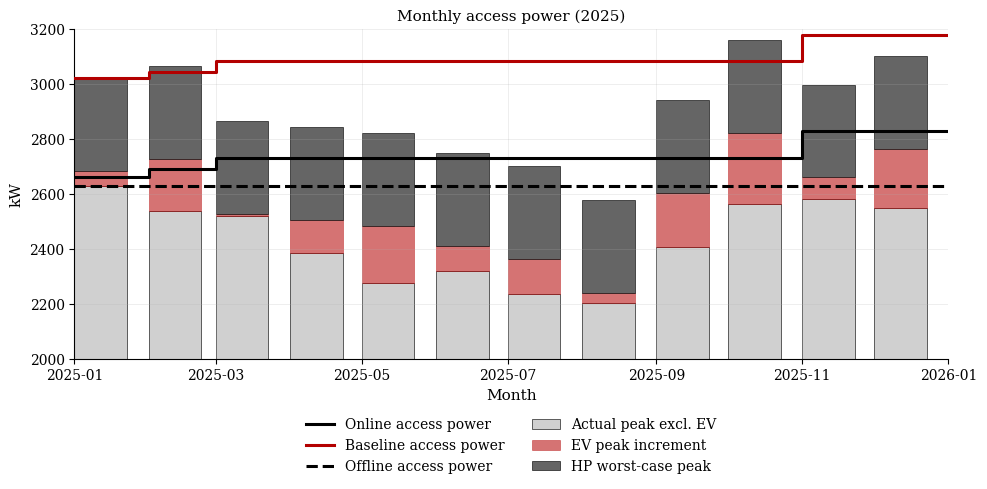

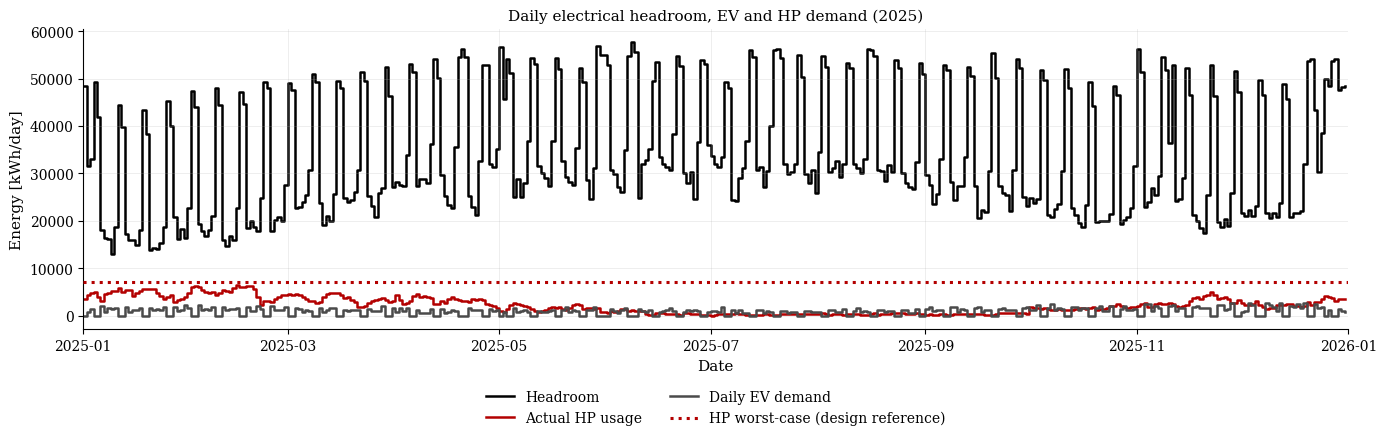

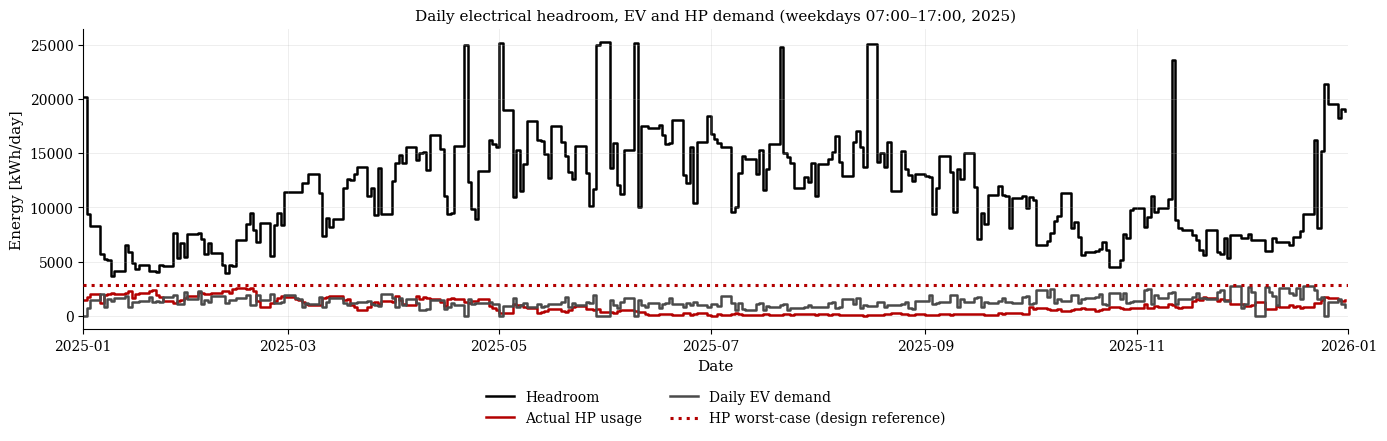

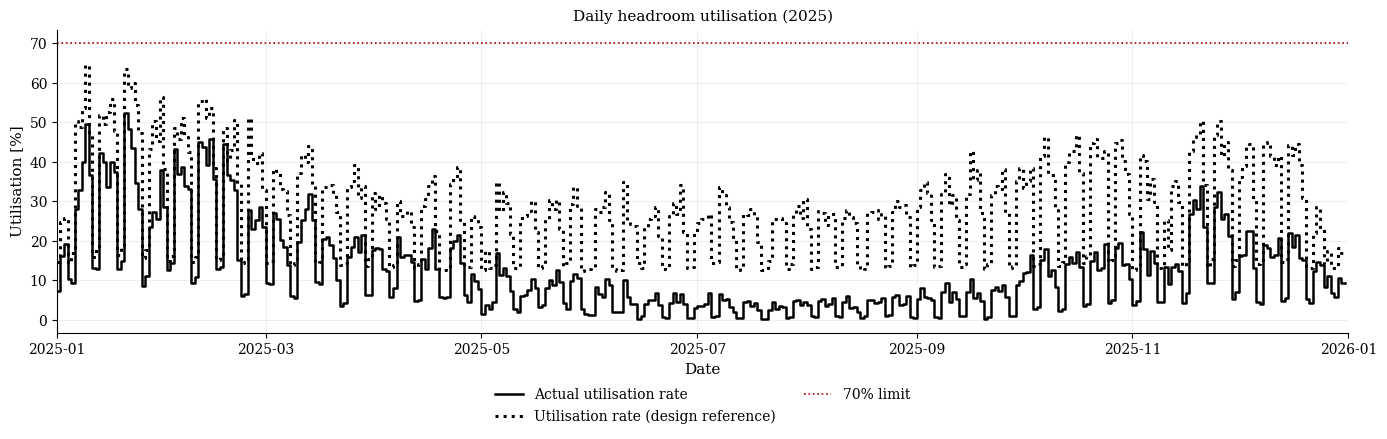

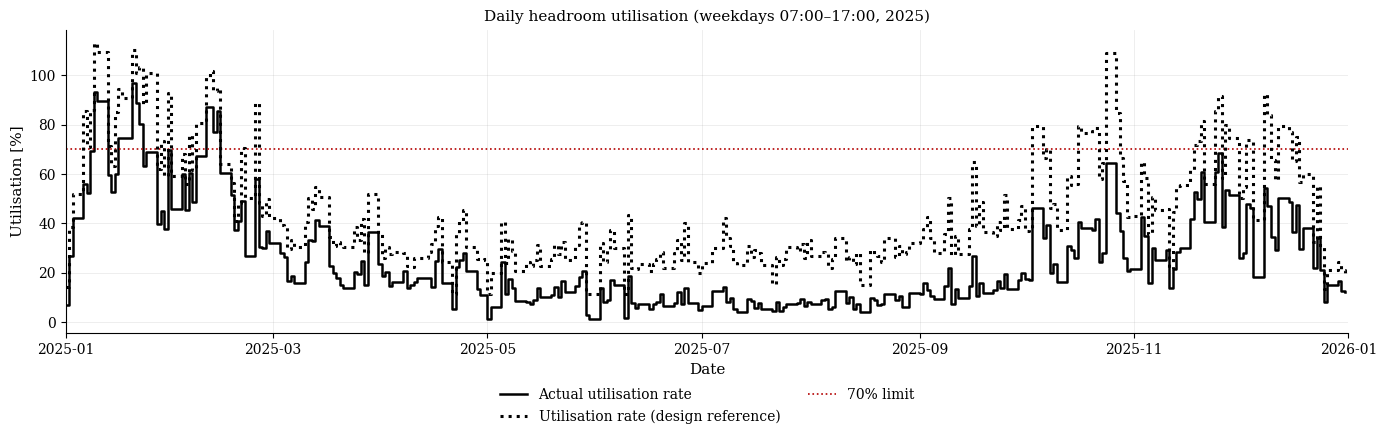

ACCESS_POWER_ONLINE_MONTHLY (flex-aware, grid, kW):


2025-01    2662.5
2025-02    2690.0
2025-03    2730.0
2025-04    2730.0
2025-05    2730.0
2025-06    2730.0
2025-07    2730.0
2025-08    2730.0
2025-09    2730.0
2025-10    2730.0
2025-11    2830.0
2025-12    2830.0
Freq: M, dtype: float64

ACCESS_POWER_BASELINE_MONTHLY (conservative, grid + HP peak, kW):


2025-01    3021.3
2025-02    3042.3
2025-03    3084.3
2025-04    3084.3
2025-05    3084.3
2025-06    3084.3
2025-07    3084.3
2025-08    3084.3
2025-09    3084.3
2025-10    3084.3
2025-11    3178.8
2025-12    3178.8
Name: baseline_access_power_kw, dtype: float64

In [1]:
# §1.2 — Access power selection (grid-based, joint EV+HP)

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path("..").resolve()
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

import importlib
import access_power_headroom

importlib.reload(access_power_headroom)
from access_power_headroom import (
    monthly_access_power_flex_hybrid,
    month_period_index_to_str_keys,
)
from heat_pump_load import interpolate_cop, load_hp_config

NOTEBOOKS_OUTPUT_DIR = PROJECT_ROOT / "output" / "notebooks"
MARGIN_KW = 20.0
months = pd.period_range("2025-01", "2025-12", freq="M")

# --- Notebook 04 exports ---
DET_EV_HP_15MIN_PATH = NOTEBOOKS_OUTPUT_DIR / "deterministic_ev_hp_15min_notebook_04.csv"
DET_EV_HP_BILLS_PATH = NOTEBOOKS_OUTPUT_DIR / "deterministic_ev_hp_monthly_bills_notebook_04.csv"
DET_EV_HP_INJ_PATH = NOTEBOOKS_OUTPUT_DIR / "deterministic_ev_hp_monthly_injection_notebook_04.csv"
DET_EV_HP_BASELINE_BILLS_PATH = (
    NOTEBOOKS_OUTPUT_DIR / "deterministic_ev_hp_monthly_baseline_bills_notebook_04.csv"
)
DET_EV_HP_BASELINE_INJ_PATH = (
    NOTEBOOKS_OUTPUT_DIR / "deterministic_ev_hp_monthly_baseline_injection_notebook_04.csv"
)
DET_EV_HP_COMPARISON_PATH = (
    NOTEBOOKS_OUTPUT_DIR / "deterministic_ev_hp_monthly_comparison_notebook_04.csv"
)
for _p in (
    DET_EV_HP_15MIN_PATH,
    DET_EV_HP_BILLS_PATH,
    DET_EV_HP_COMPARISON_PATH,
):
    if not _p.exists():
        raise FileNotFoundError(f"Run notebook 04 export cell first: {_p}")

DET_EV_HP_15MIN = pd.read_csv(DET_EV_HP_15MIN_PATH)
DET_EV_HP_MONTHLY_BILLS = pd.read_csv(DET_EV_HP_BILLS_PATH)
DET_EV_HP_MONTHLY_INJ = pd.read_csv(DET_EV_HP_INJ_PATH)
DET_EV_HP_BASELINE_BILLS = pd.read_csv(DET_EV_HP_BASELINE_BILLS_PATH)
DET_EV_HP_BASELINE_INJ = pd.read_csv(DET_EV_HP_BASELINE_INJ_PATH)
DET_EV_HP_MONTHLY_COMPARISON = pd.read_csv(DET_EV_HP_COMPARISON_PATH)

if "timestamp" in DET_EV_HP_15MIN.columns:
    DET_EV_HP_15MIN["timestamp"] = pd.to_datetime(DET_EV_HP_15MIN["timestamp"], errors="coerce")

det_bills_ap = DET_EV_HP_MONTHLY_BILLS.copy()
if "month" in det_bills_ap.columns:
    det_bills_ap["month_key"] = det_bills_ap["month"].astype(str)
access_power_deterministic_kw = (
    det_bills_ap.set_index("month_key")["access_power_kw"].astype(float)
)

det_comparison = DET_EV_HP_MONTHLY_COMPARISON.copy()
if "month" in det_comparison.columns:
    det_comparison["month_key"] = det_comparison["month"].astype(str)
access_power_conservative_kw = (
    det_comparison.set_index("month_key")["baseline_access_power_kw"]
    .astype(float)
    .reindex(months.astype(str))
)

# --- Plant 2025 ---
plant = pd.read_csv(PROJECT_ROOT / "data" / "plant1.csv")
plant["timestamp"] = pd.to_datetime(plant["timestamp"], utc=True, errors="coerce")
plant["timestamp"] = plant["timestamp"].dt.tz_convert("Europe/Brussels").dt.tz_localize(None)
plant = plant.sort_values("timestamp").reset_index(drop=True)

plant_2025 = plant.loc[plant["timestamp"].dt.year == 2025].copy()
for _c in ("grid_consumption", "grid_consumption_excl_ev", "thermal_load", "ev"):
    if _c in plant_2025.columns:
        plant_2025[_c] = pd.to_numeric(plant_2025[_c], errors="coerce").fillna(0.0)
plant_2025["month"] = plant_2025["timestamp"].dt.to_period("M")

hp_cfg = load_hp_config(str(PROJECT_ROOT / "config" / "hp.yaml"))
cop_minus10 = float(interpolate_cop(-10.0, hp_cfg["COP_data"]))
max_thermal_kwh = float(plant_2025["thermal_load"].max())
hp_peak_elec_kw = max_thermal_kwh * 4.0 / cop_minus10

monthly_peak_2025_grid_kw = (
    plant_2025.groupby("month")["grid_consumption"].max() * 4.0
).reindex(months).astype(float)
monthly_peak_2025_excl_ev_kw = (
    plant_2025.groupby("month")["grid_consumption_excl_ev"].max() * 4.0
).reindex(months).astype(float)

# --- 2024 training peaks (grid_consumption_excl_ev) ---
train_2024_path = PROJECT_ROOT / "data" / "plant1_2024_training.csv"
train_2024 = pd.read_csv(train_2024_path)
train_2024["month"] = pd.PeriodIndex(train_2024["timestamp"].astype(str).str.slice(0, 7), freq="M")
train_2024["grid_consumption"] = pd.to_numeric(
    train_2024["grid_consumption"], errors="coerce"
).fillna(0.0)
train_2024["grid_consumption_excl_ev"] = pd.to_numeric(
    train_2024["grid_consumption_excl_ev"], errors="coerce"
).fillna(0.0)
train_2024["ev"] = pd.to_numeric(train_2024["ev"], errors="coerce").fillna(0.0)
monthly_peak_2024_grid_kw = train_2024.groupby("month")["grid_consumption"].max() * 4.0
monthly_peak_2024_excl_ev_kw = (
    train_2024.groupby("month")["grid_consumption_excl_ev"].max() * 4.0
)
baseline_2024_peak_excl_ev_kw = float(monthly_peak_2024_excl_ev_kw.max())
months_2024 = monthly_peak_2024_excl_ev_kw.sort_index().index

cummax_2024_grid_Mm1_kw = monthly_peak_2024_grid_kw.cummax().shift(1)
cummax_2024_grid_Mm1_kw.loc[months_2024.min()] = float(monthly_peak_2024_grid_kw.iloc[0])
cummax_2024_grid_Mm1_kw = cummax_2024_grid_Mm1_kw.fillna(float(monthly_peak_2024_grid_kw.iloc[0]))
access_power_conservative_2024_kw = cummax_2024_grid_Mm1_kw + MARGIN_KW + hp_peak_elec_kw

cummax_2024_excl_ev_Mm1_kw = monthly_peak_2024_excl_ev_kw.cummax().shift(1)
cummax_2024_excl_ev_Mm1_kw.loc[months_2024.min()] = float(monthly_peak_2024_excl_ev_kw.iloc[0])
cummax_2024_excl_ev_Mm1_kw = cummax_2024_excl_ev_Mm1_kw.fillna(float(monthly_peak_2024_excl_ev_kw.iloc[0]))
access_power_flex_aware_2024_kw = cummax_2024_excl_ev_Mm1_kw + MARGIN_KW

# Worst-case daily HP @ -10°C (2025) for 70% access rule and util plots
_hp_daily_2025 = (
    plant_2025.groupby(plant_2025["timestamp"].dt.normalize())["thermal_load"]
    .sum()
    / cop_minus10
)
hp_need_worst_day_kwh = float(_hp_daily_2025.max())

# Flex-aware (Part 2): max(cum-max grid excl. EV, 70%-cap search on M-1 month)
access_power_flex_aware_kw, flex_access_breakdown = monthly_access_power_flex_hybrid(
    train_2024,
    plant_2025,
    months,
    monthly_peak_excl_ev_kw=monthly_peak_2025_excl_ev_kw,
    baseline_2024_peak_excl_ev_kw=baseline_2024_peak_excl_ev_kw,
    hp_worst_day_kwh=hp_need_worst_day_kwh,
    margin_kw=MARGIN_KW,
    util_cap=0.70,
    step_kw=10.0,
)
cummax_excl_ev_Mm1_kw = flex_access_breakdown["access_power_flex_cummax"] - MARGIN_KW

ACCESS_POWER_ONLINE_MONTHLY = access_power_flex_aware_kw.copy()
ACCESS_POWER_BASELINE_MONTHLY = access_power_conservative_kw.copy()
ACCESS_POWER_FLEX_DICT = month_period_index_to_str_keys(access_power_flex_aware_kw)
ACCESS_POWER_DETERMINISTIC_DICT = access_power_deterministic_kw.astype(float).to_dict()
ACCESS_POWER_DICT = ACCESS_POWER_FLEX_DICT  # active online contract; set in Part 2

table = pd.DataFrame(
    {
        "actual_monthly_peak_kw_excl_ev": monthly_peak_2025_excl_ev_kw.values,
        "actual_monthly_peak_kw_grid": monthly_peak_2025_grid_kw.values,
        "hp_worst_case_peak_kw": np.full(len(months), hp_peak_elec_kw),
        "cummax_excl_ev_kw_M_minus_1": cummax_excl_ev_Mm1_kw.values,
        "access_power_flex_cummax": flex_access_breakdown["access_power_flex_cummax"].values,
        "access_power_flex_70pct_raw": flex_access_breakdown["access_power_flex_70pct_raw"].values,
        "access_power_flex_70pct_cummax": flex_access_breakdown[
            "access_power_flex_70pct_cummax"
        ].values,
        "access_power_flex_aware": access_power_flex_aware_kw.values,
        "access_power_conservative": access_power_conservative_kw.values,
        "access_power_deterministic": access_power_deterministic_kw.reindex(months.astype(str)).values,
    },
    index=[str(m) for m in months],
)
print(table.round(1))

# --- plant_hr for headroom (2024–2025 grid + EV; 2025 HP need) ---
train_2024_ts = pd.to_datetime(train_2024["timestamp"], utc=True, errors="coerce")
train_2024_ts = train_2024_ts.dt.tz_convert("Europe/Brussels").dt.tz_localize(None)

_hr_cols = ["timestamp", "grid_consumption", "ev"]
plant_hr = pd.concat(
    [
        train_2024.assign(timestamp=train_2024_ts)[_hr_cols],
        plant_2025[_hr_cols],
    ],
    ignore_index=True,
).sort_values("timestamp")
for _c in ("grid_consumption", "ev"):
    plant_hr[_c] = pd.to_numeric(plant_hr[_c], errors="coerce").fillna(0.0)

_ev_daily_hr = plant_hr.groupby(plant_hr["timestamp"].dt.normalize())["ev"].sum()
_first_ev_day = _ev_daily_hr[_ev_daily_hr > 1.0].index.min()
if pd.notna(_first_ev_day):
    plant_hr = plant_hr[plant_hr["timestamp"].dt.normalize() >= _first_ev_day].copy()


def _cop_from_temp(temp_c: float, cop_data: dict) -> float:
    if temp_c is None or (isinstance(temp_c, float) and np.isnan(temp_c)):
        return cop_minus10
    return float(interpolate_cop(float(temp_c), cop_data))


plant_hr_hp = plant_2025[["timestamp", "thermal_load", "outdoor_temperature"]].copy()
plant_hr_hp["thermal_load"] = pd.to_numeric(plant_hr_hp["thermal_load"], errors="coerce").fillna(0.0)
plant_hr_hp["outdoor_temperature"] = pd.to_numeric(
    plant_hr_hp["outdoor_temperature"], errors="coerce"
)
plant_hr_hp["cop_actual"] = plant_hr_hp["outdoor_temperature"].map(
    lambda t: _cop_from_temp(t, hp_cfg["COP_data"])
)
plant_hr_hp["hp_need_actual_kwh_15"] = plant_hr_hp["thermal_load"] / plant_hr_hp["cop_actual"]
plant_hr_hp["hp_need_minus10_kwh_15"] = plant_hr_hp["thermal_load"] / cop_minus10


def _daily_headroom_kwh(ts, load_kwh_15, access_by_month, interval_mask=None):
    access_kw = access_by_month.reindex(ts.dt.to_period("M")).to_numpy(dtype=float)
    headroom_kw = np.maximum(access_kw - 4.0 * np.asarray(load_kwh_15, dtype=float), 0.0)
    h_kwh = headroom_kw * 0.25
    dates = ts.dt.normalize().to_numpy()
    if interval_mask is not None:
        h_kwh = h_kwh[interval_mask]
        dates = dates[interval_mask]
    return (
        pd.DataFrame({"date": dates, "h": h_kwh})
        .groupby("date")["h"]
        .sum()
    )


def _daily_sum_kwh(ts, kwh_15, interval_mask=None, value_name: str = "v") -> pd.Series:
    dates = ts.dt.normalize().to_numpy()
    v = np.asarray(kwh_15, dtype=float)
    if interval_mask is not None:
        dates = dates[interval_mask]
        v = v[interval_mask]
    return pd.DataFrame({"date": dates, value_name: v}).groupby("date")[value_name].sum()


def _daily_hp_kwh(hp_df: pd.DataFrame, col: str, interval_mask=None) -> pd.Series:
    df = hp_df[["timestamp", col]].copy()
    if interval_mask is not None:
        df = df.loc[interval_mask]
    return (
        pd.DataFrame({"date": df["timestamp"].dt.normalize(), "hp": df[col]})
        .groupby("date")["hp"]
        .sum()
    )


access_power_by_month_flex_hr = pd.concat(
    [access_power_flex_aware_2024_kw, access_power_flex_aware_kw]
)

ts_hr = plant_hr["timestamp"]
grid_kwh = plant_hr["grid_consumption"].to_numpy(dtype=float)
ev_kwh = plant_hr["ev"].to_numpy(dtype=float)
ev_window = (
    (ts_hr.dt.dayofweek < 5)
    & (ts_hr.dt.hour + ts_hr.dt.minute / 60.0 >= 7.0)
    & (ts_hr.dt.hour + ts_hr.dt.minute / 60.0 < 17.0)
).to_numpy()

daily_h_flex = _daily_headroom_kwh(ts_hr, grid_kwh, access_power_by_month_flex_hr)
daily_h_flex_win = _daily_headroom_kwh(
    ts_hr, grid_kwh, access_power_by_month_flex_hr, interval_mask=ev_window
)
daily_ev_kwh = _daily_sum_kwh(ts_hr, ev_kwh, value_name="ev").reindex(daily_h_flex.index).fillna(0.0)
daily_ev_kwh_win = _daily_sum_kwh(
    ts_hr, ev_kwh, interval_mask=ev_window, value_name="ev"
).reindex(daily_h_flex_win.index).fillna(0.0)

daily_hp_need_actual_kwh = _daily_hp_kwh(plant_hr_hp, "hp_need_actual_kwh_15").reindex(
    daily_h_flex.index
)
daily_hp_need_minus10_kwh = _daily_hp_kwh(plant_hr_hp, "hp_need_minus10_kwh_15")
hp_need_worst_day_kwh_plot = float(daily_hp_need_minus10_kwh.max())
_worst_day = daily_hp_need_minus10_kwh.idxmax()

ts_hp = plant_hr_hp["timestamp"]
ev_win_hp = (
    (ts_hp.dt.dayofweek < 5)
    & (ts_hp.dt.hour + ts_hp.dt.minute / 60.0 >= 7.0)
    & (ts_hp.dt.hour + ts_hp.dt.minute / 60.0 < 17.0)
)
daily_hp_need_actual_win_kwh = _daily_hp_kwh(
    plant_hr_hp, "hp_need_actual_kwh_15", interval_mask=ev_win_hp.to_numpy()
)
daily_hp_need_minus10_win_kwh = _daily_hp_kwh(
    plant_hr_hp, "hp_need_minus10_kwh_15", interval_mask=ev_win_hp.to_numpy()
)
hp_need_worst_window_kwh = float(daily_hp_need_minus10_win_kwh.max())
_worst_hp_window_day = daily_hp_need_minus10_win_kwh.idxmax()

print(
    f"Worst-case daily HP electrical need @ COP(-10°C): {hp_need_worst_day_kwh_plot:.1f} kWh/d "
    f"(thermal peak day {_worst_day.date()})"
)
print(
    f"Worst-case HP need weekdays 07:00–17:00 @ COP(-10°C): {hp_need_worst_window_kwh:.1f} kWh "
    f"(day {_worst_hp_window_day.date()})"
)

hr_dates = pd.to_datetime(daily_h_flex.index)
_daily_ev_full = daily_ev_kwh.reindex(daily_h_flex.index).fillna(0.0)
_daily_hp_actual_full = daily_hp_need_actual_kwh.reindex(daily_h_flex.index).fillna(0.0)
util_flex_pct = np.where(
    daily_h_flex > 1e-9,
    100.0 * (_daily_ev_full + _daily_hp_actual_full) / daily_h_flex,
    np.nan,
)
util_worst_flex_pct = np.where(
    daily_h_flex > 1e-9,
    100.0 * (_daily_ev_full + hp_need_worst_day_kwh_plot) / daily_h_flex,
    np.nan,
)

daily_h_flex_win_2025 = daily_h_flex_win.reindex(
    pd.to_datetime(daily_h_flex_win.index)
)
daily_h_flex_win_2025 = daily_h_flex_win_2025[
    pd.to_datetime(daily_h_flex_win_2025.index).year == 2025
]
util_actual_win_pct = np.where(
    daily_h_flex_win_2025 > 1e-9,
    100.0
    * (
        daily_ev_kwh_win.reindex(daily_h_flex_win_2025.index).fillna(0.0)
        + daily_hp_need_actual_win_kwh.reindex(daily_h_flex_win_2025.index).fillna(0.0)
    )
    / daily_h_flex_win_2025,
    np.nan,
)
util_worst_win_pct = np.where(
    daily_h_flex_win_2025 > 1e-9,
    100.0
    * (
        daily_ev_kwh_win.reindex(daily_h_flex_win_2025.index).fillna(0.0)
        + hp_need_worst_window_kwh
    )
    / daily_h_flex_win_2025,
    np.nan,
)

# --- §1.2 plots (notebook 10 layout) ---
import matplotlib as mpl

THESIS_STYLE = {
    "font.family": "serif",
    "font.size": 11,
    "axes.labelsize": 11,
    "axes.titlesize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.linewidth": 0.8,
    "text.color": "black",
    "axes.labelcolor": "black",
    "xtick.color": "black",
    "ytick.color": "black",
    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linewidth": 0.6,
    "lines.linewidth": 2.2,
    "savefig.dpi": 300,
}
mpl.rcParams.update(THESIS_STYLE)

C_BLACK = "#000000"
C_KUL_RED = "#b30000"
C_BAR_PEAK = "#666666"
C_BAR_LIGHT = "#c8c8c8"
C_BAR_DARK = "#4a4a4a"
LW_ACCESS = 2.2
LW_DAILY = 1.8
_LGND_BOTTOM = dict(loc="upper center", bbox_to_anchor=(0.5, -0.14), ncol=2, frameon=False)
_LGND_HR = dict(loc="upper center", bbox_to_anchor=(0.5, -0.16), ncol=2, frameon=False)
_LGND_UTIL = dict(loc="upper center", bbox_to_anchor=(0.5, -0.14), ncol=2, frameon=False)
_X_START_2025 = pd.Timestamp("2025-01-01")
_X_END_2025 = pd.Timestamp("2026-01-01")

month_ts = months.to_timestamp()
month_ts_step = pd.DatetimeIndex([*month_ts, _X_END_2025])


def _extend_step_y(y_month: pd.Series | np.ndarray) -> np.ndarray:
    y = np.asarray(y_month, dtype=float)
    return np.r_[y, y[-1]]


peak_excl_kw = monthly_peak_2025_excl_ev_kw.values.astype(float)
peak_ev_incr_kw = np.maximum(
    (monthly_peak_2025_grid_kw - monthly_peak_2025_excl_ev_kw).values.astype(float), 0.0
)
hp_bar_kw = np.full(len(months), hp_peak_elec_kw, dtype=float)
_bar_w_days = 22

fig_acc, ax_acc = plt.subplots(figsize=(10, 5))
ax_acc.bar(
    month_ts,
    peak_excl_kw,
    width=_bar_w_days,
    align="edge",
    color=C_BAR_LIGHT,
    alpha=0.85,
    edgecolor=C_BLACK,
    linewidth=0.5,
    label="Actual peak excl. EV",
    zorder=1,
)
ax_acc.bar(
    month_ts,
    peak_ev_incr_kw,
    width=_bar_w_days,
    bottom=peak_excl_kw,
    align="edge",
    color=C_KUL_RED,
    alpha=0.55,
    edgecolor=C_KUL_RED,
    linewidth=0.5,
    label="EV peak increment",
    zorder=1,
)
ax_acc.bar(
    month_ts,
    hp_bar_kw,
    width=_bar_w_days,
    bottom=peak_excl_kw + peak_ev_incr_kw,
    align="edge",
    color=C_BAR_DARK,
    alpha=0.85,
    edgecolor=C_BLACK,
    linewidth=0.5,
    label="HP worst-case peak",
    zorder=1,
)
ax_acc.step(
    month_ts_step,
    _extend_step_y(access_power_flex_aware_kw.values),
    where="post",
    color=C_BLACK,
    linewidth=LW_ACCESS,
    linestyle="-",
    label="Online access power",
    zorder=3,
)
ax_acc.step(
    month_ts_step,
    _extend_step_y(access_power_conservative_kw.values),
    where="post",
    color=C_KUL_RED,
    linewidth=LW_ACCESS,
    linestyle="-",
    label="Baseline access power",
    zorder=3,
)
ax_acc.step(
    month_ts_step,
    _extend_step_y(access_power_deterministic_kw.reindex(months.astype(str)).values),
    where="post",
    color=C_BLACK,
    linewidth=LW_ACCESS,
    linestyle="--",
    label="Offline access power",
    zorder=3,
)
ax_acc.set_title("Monthly access power (2025)")
ax_acc.set_ylabel("kW")
ax_acc.set_xlabel("Month")
ax_acc.set_ylim(2000, 3200)
ax_acc.set_xlim(_X_START_2025, _X_END_2025)
ax_acc.margins(x=0)
ax_acc.legend(**_LGND_BOTTOM)
fig_acc.subplots_adjust(bottom=0.26)
plt.tight_layout()
plt.show()

idx_2025 = (
    pd.DatetimeIndex(pd.to_datetime(daily_h_flex.index))
    .normalize()
    .unique()
    .sort_values()
)
idx_2025 = idx_2025[idx_2025.year == 2025]

df_hr_2025 = pd.DataFrame(
    {
        "headroom": daily_h_flex.reindex(idx_2025),
        "hp_actual": daily_hp_need_actual_kwh.reindex(idx_2025),
        "ev_actual": daily_ev_kwh.reindex(idx_2025),
    },
    index=idx_2025,
).astype(float)
df_hr_2025["hp_actual"] = df_hr_2025["hp_actual"].replace([np.inf, -np.inf], np.nan)
df_hr_2025["ev_actual"] = df_hr_2025["ev_actual"].replace([np.inf, -np.inf], np.nan)
hp_design_ref_kwh_d = float(hp_need_worst_day_kwh_plot)

idx_2025_win = idx_2025.intersection(pd.to_datetime(daily_h_flex_win.index))
df_hr_win_2025 = pd.DataFrame(
    {
        "headroom": daily_h_flex_win.reindex(idx_2025_win),
        "hp_actual": daily_hp_need_actual_win_kwh.reindex(idx_2025_win),
        "ev_actual": daily_ev_kwh_win.reindex(idx_2025_win),
    },
    index=idx_2025_win,
).astype(float)
df_hr_win_2025["hp_actual"] = df_hr_win_2025["hp_actual"].replace([np.inf, -np.inf], np.nan)
df_hr_win_2025["ev_actual"] = df_hr_win_2025["ev_actual"].replace([np.inf, -np.inf], np.nan)

util_worst_2025 = pd.Series(
    np.asarray(util_worst_flex_pct, dtype=float), index=hr_dates
).reindex(idx_2025)
util_actual_2025 = pd.Series(
    np.asarray(util_flex_pct, dtype=float), index=hr_dates
).reindex(idx_2025)

fig_hr, ax_hr = plt.subplots(figsize=(14, 4.5))
ax_hr.plot(
    df_hr_2025.index,
    df_hr_2025["headroom"],
    drawstyle="steps-post",
    color=C_BLACK,
    linewidth=LW_DAILY,
    label="Headroom",
    zorder=1,
)
ax_hr.plot(
    df_hr_2025.index,
    df_hr_2025["hp_actual"],
    drawstyle="steps-post",
    color=C_KUL_RED,
    linewidth=LW_DAILY,
    linestyle="-",
    label="Actual HP usage",
    zorder=2,
)
ax_hr.plot(
    df_hr_2025.index,
    df_hr_2025["ev_actual"],
    drawstyle="steps-post",
    color=C_BAR_DARK,
    linewidth=LW_DAILY,
    linestyle="-",
    label="Daily EV demand",
    zorder=2,
)
ax_hr.axhline(
    hp_design_ref_kwh_d,
    color=C_KUL_RED,
    linewidth=LW_DAILY + 0.4,
    linestyle=":",
    label="HP worst-case (design reference)",
    zorder=3,
)
ax_hr.set_title("Daily electrical headroom, EV and HP demand (2025)")
ax_hr.set_ylabel("Energy [kWh/day]")
ax_hr.set_xlabel("Date")
ax_hr.set_xlim(_X_START_2025, _X_END_2025)
ax_hr.margins(x=0)
ax_hr.legend(**_LGND_HR)
fig_hr.subplots_adjust(bottom=0.28)
plt.tight_layout()
plt.show()

fig_hr_win, ax_hr_win = plt.subplots(figsize=(14, 4.5))
ax_hr_win.plot(
    df_hr_win_2025.index,
    df_hr_win_2025["headroom"],
    drawstyle="steps-post",
    color=C_BLACK,
    linewidth=LW_DAILY,
    label="Headroom",
    zorder=1,
)
ax_hr_win.plot(
    df_hr_win_2025.index,
    df_hr_win_2025["hp_actual"],
    drawstyle="steps-post",
    color=C_KUL_RED,
    linewidth=LW_DAILY,
    linestyle="-",
    label="Actual HP usage",
    zorder=2,
)
ax_hr_win.plot(
    df_hr_win_2025.index,
    df_hr_win_2025["ev_actual"],
    drawstyle="steps-post",
    color=C_BAR_DARK,
    linewidth=LW_DAILY,
    linestyle="-",
    label="Daily EV demand",
    zorder=2,
)
ax_hr_win.axhline(
    hp_need_worst_window_kwh,
    color=C_KUL_RED,
    linewidth=LW_DAILY + 0.4,
    linestyle=":",
    label="HP worst-case (design reference)",
    zorder=3,
)
ax_hr_win.set_title("Daily electrical headroom, EV and HP demand (weekdays 07:00–17:00, 2025)")
ax_hr_win.set_ylabel("Energy [kWh/day]")
ax_hr_win.set_xlabel("Date")
ax_hr_win.set_xlim(_X_START_2025, _X_END_2025)
ax_hr_win.margins(x=0)
ax_hr_win.legend(**_LGND_HR)
fig_hr_win.subplots_adjust(bottom=0.28)
plt.tight_layout()
plt.show()

fig_u, ax_u = plt.subplots(figsize=(14, 4.5))
ax_u.plot(
    idx_2025,
    util_actual_2025,
    drawstyle="steps-post",
    color=C_BLACK,
    linewidth=LW_DAILY,
    linestyle="-",
    label="Actual utilisation rate",
    zorder=2,
)
ax_u.plot(
    idx_2025,
    util_worst_2025,
    drawstyle="steps-post",
    color=C_BLACK,
    linewidth=LW_DAILY + 0.4,
    linestyle=":",
    label="Utilisation rate (design reference)",
    zorder=3,
)
ax_u.axhline(70.0, color=C_KUL_RED, linewidth=1.2, linestyle=":", label="70% limit")
ax_u.set_title("Daily headroom utilisation (2025)")
ax_u.set_ylabel("Utilisation [%]")
ax_u.set_xlabel("Date")
ax_u.set_xlim(_X_START_2025, _X_END_2025)
ax_u.margins(x=0)
ax_u.legend(**_LGND_UTIL)
fig_u.subplots_adjust(bottom=0.24)
plt.tight_layout()
plt.show()

idx_2025_win_util = pd.DatetimeIndex(daily_h_flex_win_2025.index).sort_values()
util_actual_win_2025 = pd.Series(
    np.asarray(util_actual_win_pct, dtype=float), index=idx_2025_win_util
)
util_worst_win_2025 = pd.Series(
    np.asarray(util_worst_win_pct, dtype=float), index=idx_2025_win_util
)

fig_u_win, ax_u_win = plt.subplots(figsize=(14, 4.5))
ax_u_win.plot(
    idx_2025_win_util,
    util_actual_win_2025,
    drawstyle="steps-post",
    color=C_BLACK,
    linewidth=LW_DAILY,
    linestyle="-",
    label="Actual utilisation rate",
    zorder=2,
)
ax_u_win.plot(
    idx_2025_win_util,
    util_worst_win_2025,
    drawstyle="steps-post",
    color=C_BLACK,
    linewidth=LW_DAILY + 0.4,
    linestyle=":",
    label="Utilisation rate (design reference)",
    zorder=3,
)
ax_u_win.axhline(70.0, color=C_KUL_RED, linewidth=1.2, linestyle=":", label="70% limit")
ax_u_win.set_title("Daily headroom utilisation (weekdays 07:00–17:00, 2025)")
ax_u_win.set_ylabel("Utilisation [%]")
ax_u_win.set_xlabel("Date")
ax_u_win.set_xlim(_X_START_2025, _X_END_2025)
ax_u_win.margins(x=0)
ax_u_win.legend(**_LGND_UTIL)
fig_u_win.subplots_adjust(bottom=0.24)
plt.tight_layout()
plt.show()

print("ACCESS_POWER_ONLINE_MONTHLY (flex-aware, grid, kW):")
display(ACCESS_POWER_ONLINE_MONTHLY.round(1))
print("ACCESS_POWER_BASELINE_MONTHLY (conservative, grid + HP peak, kW):")
display(ACCESS_POWER_BASELINE_MONTHLY.round(1))


## Part 2 — Rolling-horizon joint simulation

In the code cell below, set **`ONLINE_ACCESS_POWER_MODE`** before running:

| Mode | Dictionary | Description |
|------|------------|-------------|
| `"flex_aware"` | `ACCESS_POWER_FLEX_DICT` | §1.2 hybrid rule (default) |
| `"deterministic"` | `ACCESS_POWER_DETERMINISTIC_DICT` | Notebook 04 optimized monthly access |

**Actuator chain** (weekday 07:00–17:00): `mpc_ev_hp_24h` → joint clip (Eq. 3.50) → optional **enforce daily EV demand** (`ENFORCE_DAILY_EV_DEMAND`; 12:00–17:00): after a clip, add only the **minimum** kWh when `ev_to_deliver` cannot still be met using envelope headroom through **17:00**; otherwise defer to catch-up (`[17:00−slack, 17:00)`) → HP PLC (SOC min/max). Diagnostics: `ev_envelope_remaining_kwh`, `ev_envelope_headroom_after_kwh`, `ev_envelope_feasible`, `ev_enforce_deferred`.

Part 3 (§3.1 plots and §3.2 billing) uses the same selection via `access_kw` in the Part 2 export. **Re-run Part 2** after changing the mode, then Part 3.


In [11]:
# Part 2 — Joint online MPC (default: nb09 EV best + nb10 HP Part 2)

import sys
from pathlib import Path

PROJECT_ROOT = Path("..").resolve()
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

NOTEBOOKS_OUTPUT_DIR = PROJECT_ROOT / "output" / "notebooks"

import importlib
import optimization
import online_MPC_1_EV_HP

importlib.reload(optimization)
importlib.reload(online_MPC_1_EV_HP)
from online_MPC_1_EV_HP import run_ev_hp_online_mpc_1

# --- Online access power contract (set before running) ---
# "flex_aware"     -> ACCESS_POWER_FLEX_DICT (§1.2 hybrid rule)
# "deterministic"  -> ACCESS_POWER_DETERMINISTIC_DICT (notebook 04 optimized access)
ONLINE_ACCESS_POWER_MODE = "flex_aware"

_REQUIRED_AP = ("ACCESS_POWER_FLEX_DICT", "ACCESS_POWER_DETERMINISTIC_DICT")
if not all(name in globals() for name in _REQUIRED_AP):
    raise RuntimeError(f"Run §1.2 first (need {', '.join(_REQUIRED_AP)}).")

_ACCESS_BY_MODE = {
    "flex_aware": ACCESS_POWER_FLEX_DICT,
    "deterministic": ACCESS_POWER_DETERMINISTIC_DICT,
}
if ONLINE_ACCESS_POWER_MODE not in _ACCESS_BY_MODE:
    raise ValueError(
        f"ONLINE_ACCESS_POWER_MODE must be one of {list(_ACCESS_BY_MODE)}; "
        f"got {ONLINE_ACCESS_POWER_MODE!r}"
    )
ACCESS_POWER_DICT = _ACCESS_BY_MODE[ONLINE_ACCESS_POWER_MODE]
print(f"Part 2 — online MPC access power mode: {ONLINE_ACCESS_POWER_MODE}")

EV_FORECAST_STRATEGY = "c_p90"
INFLEX_FORECAST_STRATEGY = "c"
PV_FORECAST_STRATEGY = "chronos2_elia_p50"
EV_DEADLINE_SLACK_MIN = 105
ENFORCE_DAILY_EV_DEMAND = True
THERMAL_FORECAST_STRATEGY = "c2t_p50"
INFLEX_FORECAST_STRATEGY_STRESS = "c_p99"
TEMP_FORECAST_STRATEGY = "open_meteo_day_ahead"
ENFORCE_SOC_MIN = True
ENFORCE_SOC_MAX = True
SOC_SLACK_PENALTY_EUR_PER_SOC = 1.0e6
ENABLE_FORECAST_STRESS_SOC_FLOOR = True
FORECAST_STRESS_SOC_FLOOR_STRENGTH = 0.75
MONTHLY_PEAK_PRICE_MULTIPLIER = 1.0

res_evhp_online, summ_evhp_online = run_ev_hp_online_mpc_1(
    forecast_strategy_ev=EV_FORECAST_STRATEGY,
    forecast_strategy_inflex=INFLEX_FORECAST_STRATEGY,
    forecast_strategy_inflex_stress=INFLEX_FORECAST_STRATEGY_STRESS,
    forecast_strategy_pv=PV_FORECAST_STRATEGY,
    forecast_strategy_thermal=THERMAL_FORECAST_STRATEGY,
    forecast_strategy_temperature=TEMP_FORECAST_STRATEGY,
    ev_deadline_slack_minutes=EV_DEADLINE_SLACK_MIN,
    enforce_daily_ev_demand=ENFORCE_DAILY_EV_DEMAND,
    access_power_by_month=ACCESS_POWER_DICT,
    enforce_soc_min=ENFORCE_SOC_MIN,
    enforce_soc_max=ENFORCE_SOC_MAX,
    soc_slack_penalty_eur_per_soc=SOC_SLACK_PENALTY_EUR_PER_SOC,
    monthly_peak_price_multiplier=MONTHLY_PEAK_PRICE_MULTIPLIER,
    enable_forecast_stress_soc_floor=ENABLE_FORECAST_STRESS_SOC_FLOOR,
    forecast_stress_soc_floor_strength=FORECAST_STRESS_SOC_FLOOR_STRENGTH,
    verbose=True,
)

RESULTS_15MIN_PATH = NOTEBOOKS_OUTPUT_DIR / "online_ev_hp_15min_notebook_11_part2.csv"
res_evhp_online.to_csv(RESULTS_15MIN_PATH, index=False)
opt_path = PROJECT_ROOT / "output" / "optimised_ts" / "online_ev_hp.csv"
opt_path.parent.mkdir(parents=True, exist_ok=True)
res_evhp_online[["timestamp", "ev_applied", "hp_applied"]].rename(
    columns={"ev_applied": "ev_online", "hp_applied": "hp_online"}
).to_csv(opt_path, index=False)
print("Saved:", RESULTS_15MIN_PATH)
print(f"  (access mode: {ONLINE_ACCESS_POWER_MODE})")


Part 2 — online MPC access power mode: flex_aware
Joint EV+HP Online MPC 1 – Full-year simulation
  EV forecast strategy:       c_p90
  Inflex forecast strategy:   c
  Inflex strategy (stress):   c_p99
  PV forecast strategy:       chronos2_elia_p50
  Thermal forecast strategy:  c2t_p50
  Temperature strategy:       open_meteo_day_ahead
  EV deadline slack (min):      105
  Enforce daily EV demand:    True
  Enforce SOC min:            True
  Enforce SOC max:            True
  Planner SOC slack penalty (€/SOC): 1000000.0
  Planner monthly peak price multiplier: 1.0
  Forecast stress SOC floor:  True (strength=0.75)
  Plant data:            C:\Users\VanAmmeT\Documents\Masterproef\Master-Thesis-MPC-Soudal\data\plant1.csv
  EV forecast:           C:\Users\VanAmmeT\Documents\Masterproef\Master-Thesis-MPC-Soudal\output\forecast\forecast_ev_rolling_horizon.csv
  Inflex forecast:       C:\Users\VanAmmeT\Documents\Masterproef\Master-Thesis-MPC-Soudal\output\forecast\forecast_inflex_load_rollin

## Part 3 — Visualisation and comparison


### §3.1 Optimised volumes

Joint **online MPC** (Part 2) vs **deterministic joint** (notebook 04) vs baselines, in the same spirit as notebook 09 (EV) and notebook 10 (HP), with EV+HP on shared axes like notebook 04.

**Inputs**

- Online: `res_evhp_online` or [`output/notebooks/online_ev_hp_15min_notebook_11_part2.csv`](../output/notebooks/online_ev_hp_15min_notebook_11_part2.csv)
- Deterministic: `DET_EV_HP_15MIN` from §1.2 or [`deterministic_ev_hp_15min_notebook_04.csv`](../output/notebooks/deterministic_ev_hp_15min_notebook_04.csv)
- Baseline EV: column `ev` in the online trace; baseline HP: [`output/uncontrolled_hp.csv`](../output/uncontrolled_hp.csv)

**Knobs** — set `WEEK_START` and `DAY_OF_WEEK` in **Part 4C** (or at the top of this cell for a direct §3.1 run). No default week is applied.

**Enforce diagnostics** (nb09-style; requires Part 2 re-run with current `src`): `ev_to_deliver_kwh`, envelope headroom columns, `ev_enforce_active` / `ev_enforce_deferred` markers on daily EV plot.

**Figures**

1. SOC violation summary (online + deterministic)
2. **Weekly** (4 thesis figures): EV power; HP electrical; buffer SOC; grid power (nb09/nb10 style; forecast-stress shading when Part 2 export includes it)
3. **Daily** (5 thesis figures, 05:00–19:00): EV power, HP electrical, buffer SOC, electricity spot price (ZOH), grid power
4. **Yearly**: daily uncharged EV; daily EV delivered (online vs det.); full-year grid comparison
5. Optional **MPC 24h window** at `DEBUG_TS` when `RUN_MPC_DEBUG=True` (requires §1.2 + forecasts)


§3.1 plot window: week 2025-02-10 – 2025-02-16, daily day 2 -> 2025-02-11

SOC violations summary (online MPC (soc_after))
SOC bounds: [0.200, 0.950]
Violation points: 220 (each = 15 min)
Violation episodes: 216
Total violated time: 55.00 h; max episode: 0.50 h

SOC violations summary (deterministic MPC (buffer_soc))
SOC bounds: [0.200, 0.950]
Violation points: 0 (each = 15 min)
Violation episodes: 0


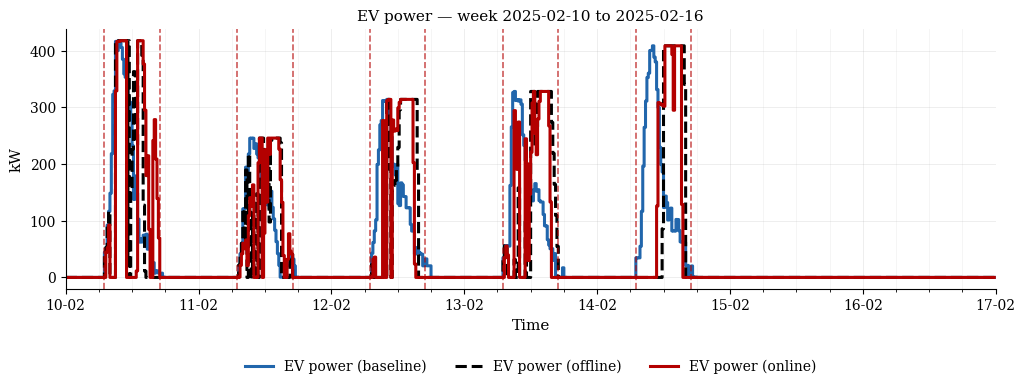

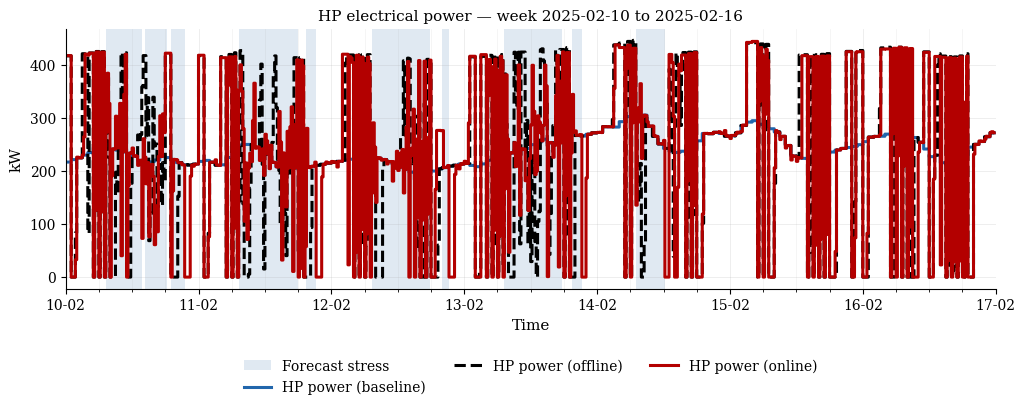

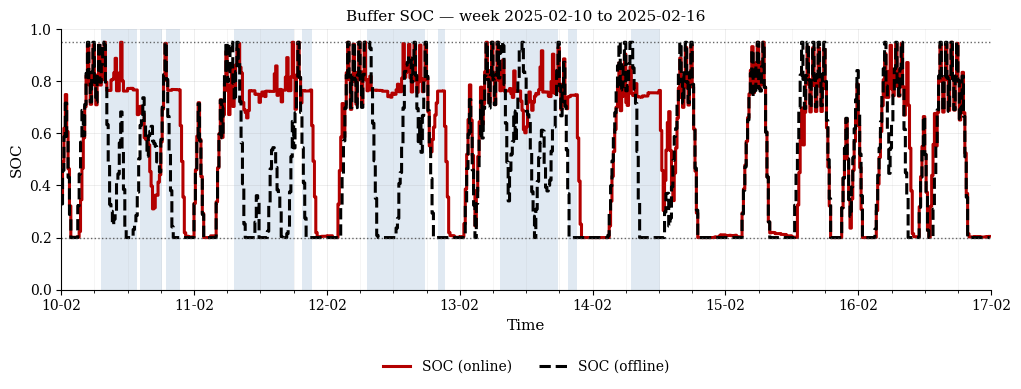

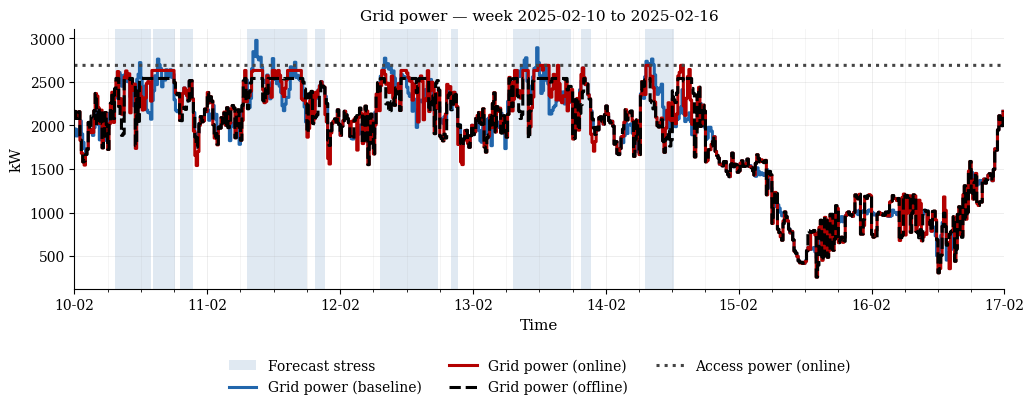

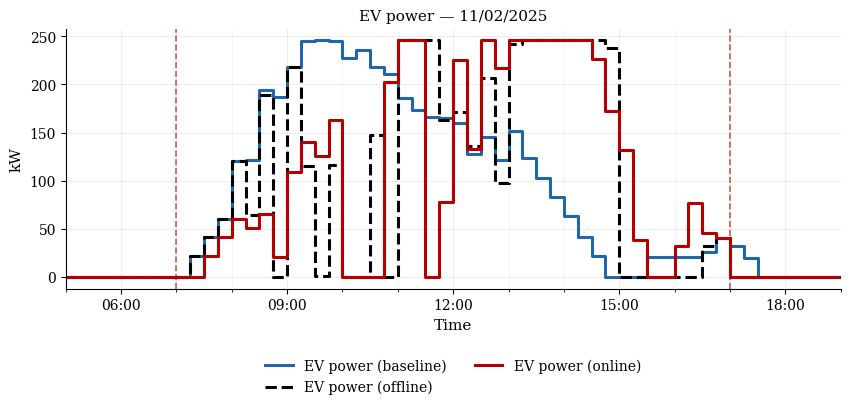

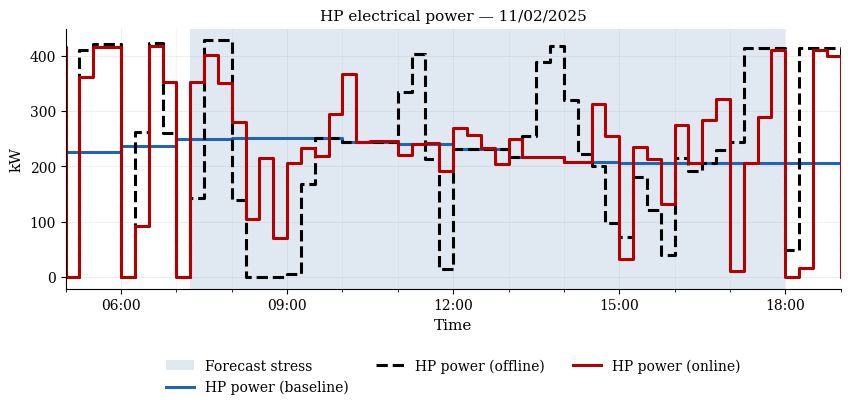

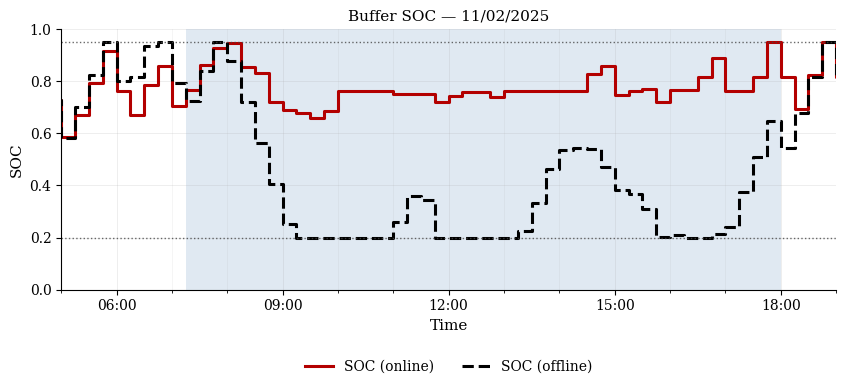

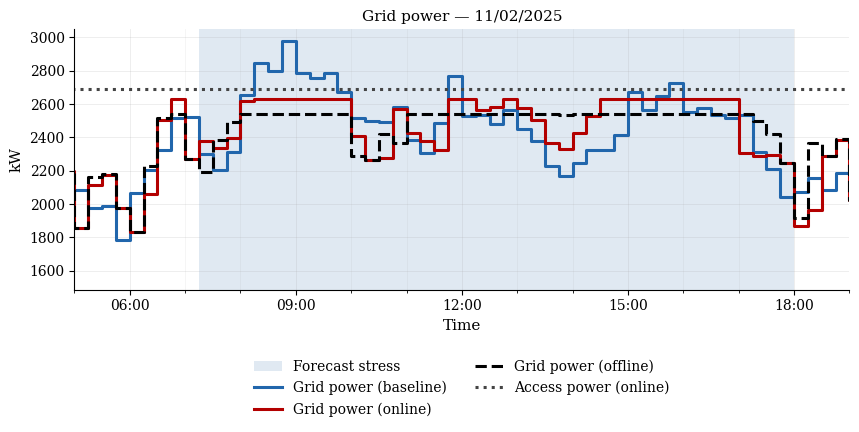


Day replay — 2025-02-11  (slack 105 min → MPC ends 15:15)
Grid peak 2631.5 kW | access 2690.0 kW | p_limit [2631.5, 2631.5] kW
Access violations: 0 steps, max exceed 0.0 kW
EV delivered 1158.4 kWh (MPC region 1099.6, catch-up 58.7)
Enforce: 2 active steps, 12.0 kWh extra | Deferred: 10 steps
EV still to deliver at MPC region end: 91.8 kWh
Catch-up max access exceed: 0.0 kW
Mechanism: p_limit ≈ min(access, max(peak_so_far, monthly_peak_plan)) in MPC region; low monthly_peak_plan holds clip below access until catch-up enforce pushes EV.


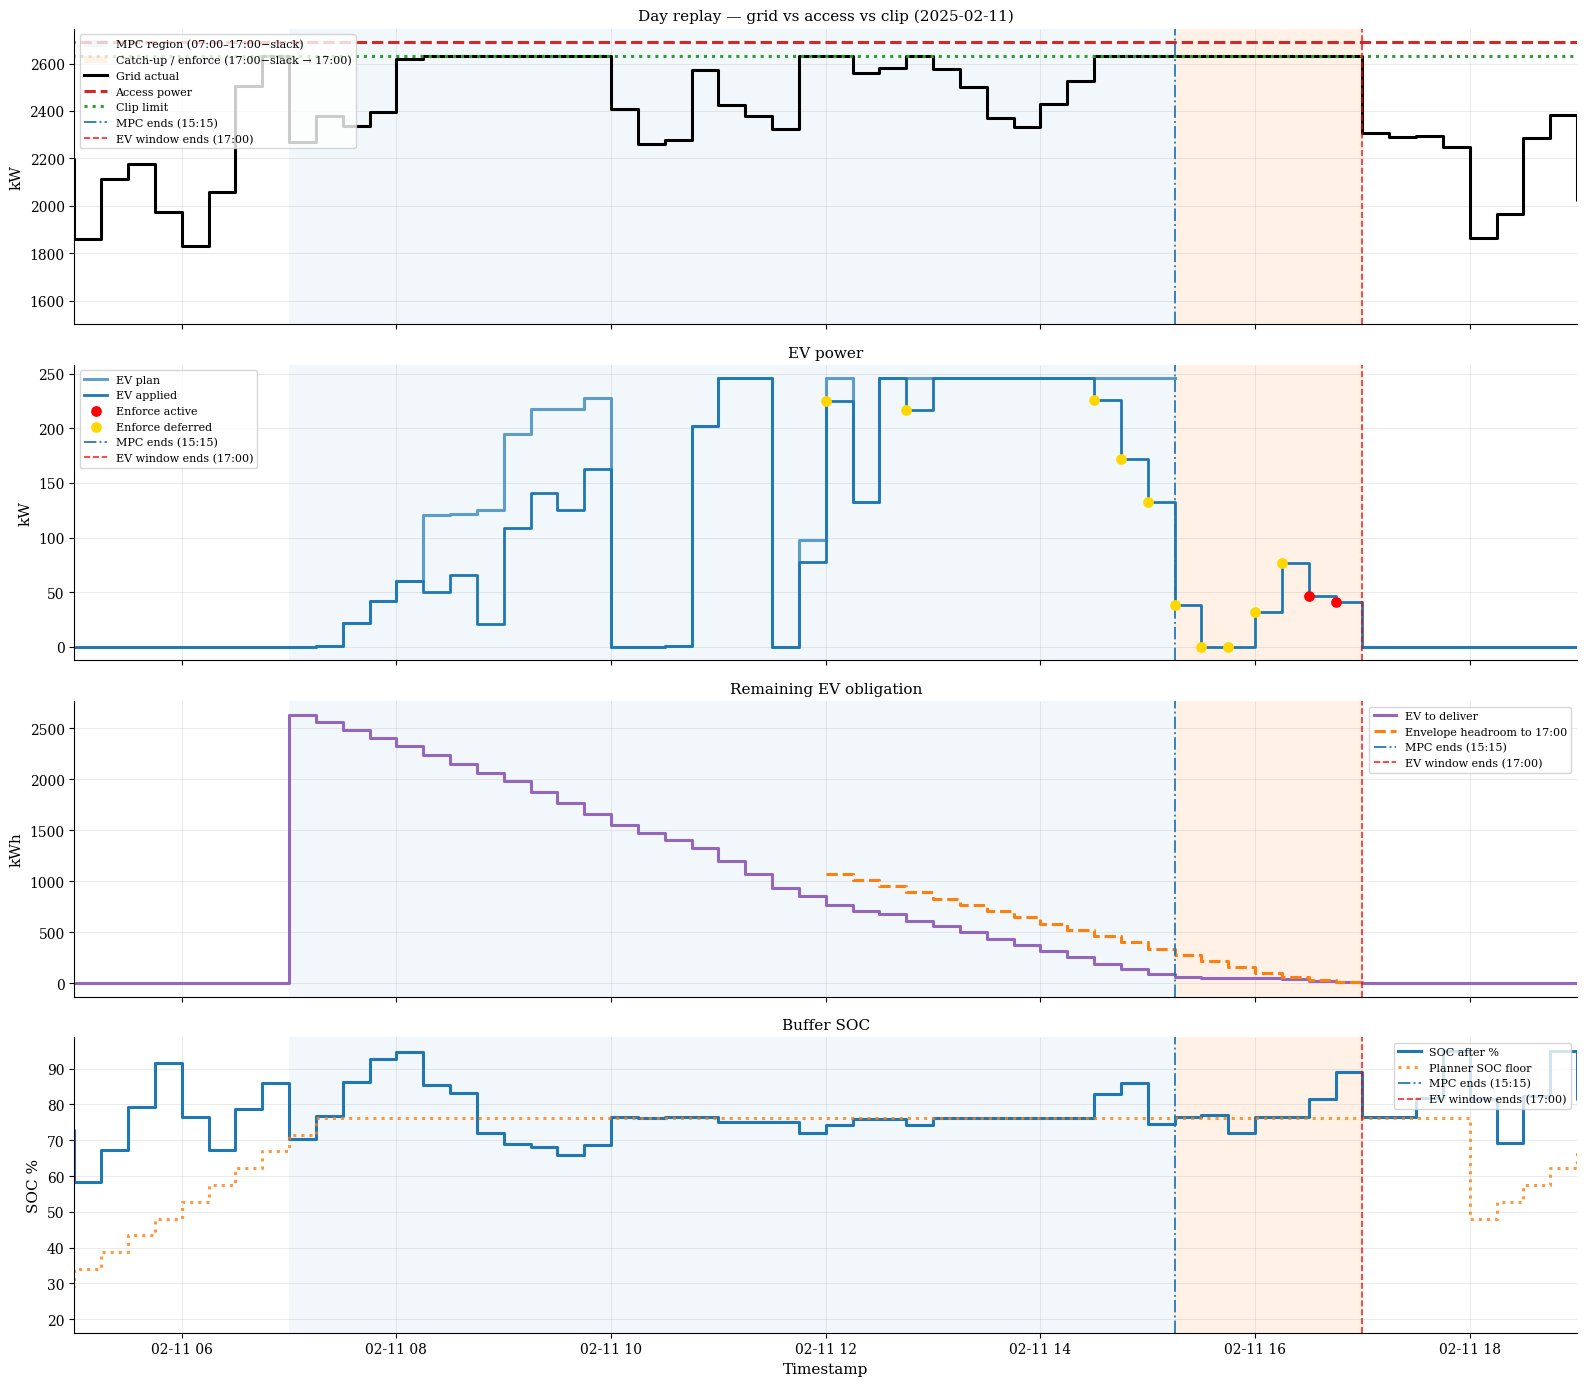


Day summary (2025-02-11): EV online 1158.4 kWh, HP online 5316.7 kWh, mean SOC 63.4%, enforce active 2 steps, deferred 10 steps


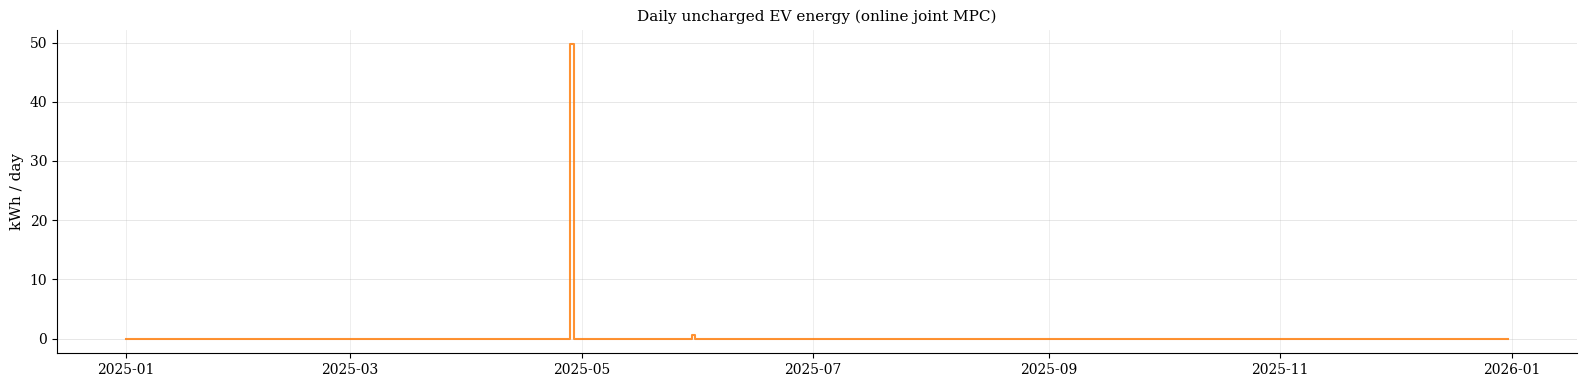

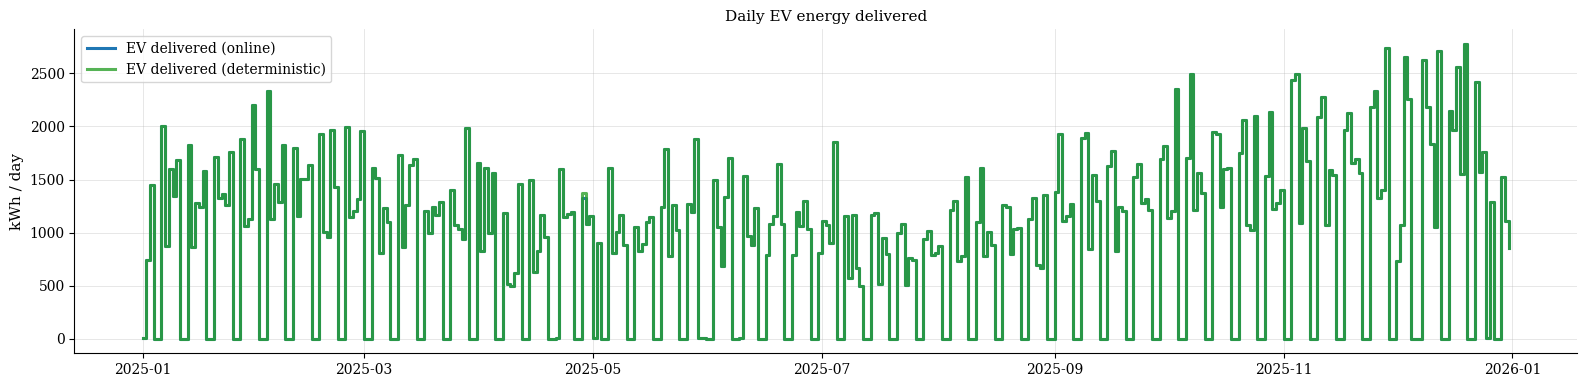

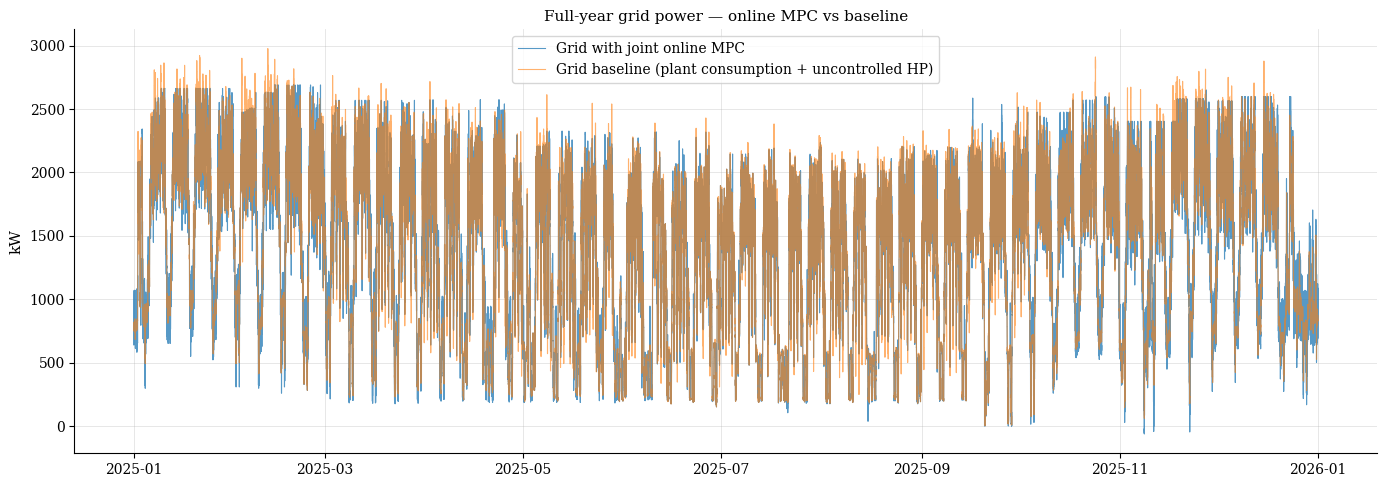


MPC 24h window debug skipped (RUN_MPC_DEBUG=False).


In [12]:
# §3.1 — Joint online optimised volumes (plots)

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml

PROJECT_ROOT = Path("..").resolve()
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))
from notebook_visualisation.nb11_evhp_day_replay import (
    plot_day_replay,
    print_day_replay_report,
    summarize_day,
    vlines_mpc_deadline,
)
from notebook_visualisation import nb11_evhp_thesis_plots as _thesis_plt
NOTEBOOKS_OUTPUT_DIR = PROJECT_ROOT / "output" / "notebooks"
RESULTS_15MIN_PATH = NOTEBOOKS_OUTPUT_DIR / "online_ev_hp_15min_notebook_11_part2.csv"
DET_EV_HP_15MIN_PATH = NOTEBOOKS_OUTPUT_DIR / "deterministic_ev_hp_15min_notebook_04.csv"
UNCONTROLLED_HP_PATH = PROJECT_ROOT / "output" / "uncontrolled_hp.csv"

# --- Plot knobs ---
# Part 4C injects ``_NB11_PART31_KNOBS`` (no default dates). Direct §3.1: set WEEK_START / DAY_OF_WEEK
# in this cell above this block before running.
_knobs = globals().pop("_NB11_PART31_KNOBS", None)
if _knobs is not None:
    WEEK_START = pd.Timestamp(_knobs["WEEK_START"])
    DAY_OF_WEEK = int(_knobs["DAY_OF_WEEK"])
    DEBUG_TS = (
        pd.Timestamp(_knobs["DEBUG_TS"])
        if _knobs.get("DEBUG_TS") is not None
        else WEEK_START + pd.Timedelta(hours=8)
    )
    RUN_MPC_DEBUG = bool(_knobs.get("RUN_MPC_DEBUG", False))
    RUN_DAY_REPLAY = bool(_knobs.get("RUN_DAY_REPLAY", True))
    EV_DEADLINE_SLACK_MIN_PLOT = int(_knobs.get("EV_DEADLINE_SLACK_MIN", 105))
elif "WEEK_START" in globals() and "DAY_OF_WEEK" in globals():
    WEEK_START = pd.Timestamp(WEEK_START)
    DAY_OF_WEEK = int(DAY_OF_WEEK)
    DEBUG_TS = pd.Timestamp(
        globals()["DEBUG_TS"] if "DEBUG_TS" in globals() else WEEK_START + pd.Timedelta(hours=8)
    )
    RUN_MPC_DEBUG = bool(globals().get("RUN_MPC_DEBUG", False))
    RUN_DAY_REPLAY = bool(globals().get("RUN_DAY_REPLAY", True))
    EV_DEADLINE_SLACK_MIN_PLOT = int(globals().get("EV_DEADLINE_SLACK_MIN", 105))
else:
    raise ValueError(
        "Set WEEK_START and DAY_OF_WEEK (Part 4C cell, or at the top of this §3.1 cell). "
        "No default week is applied."
    )

WEEK_END = WEEK_START + pd.Timedelta(days=7)
year_start = pd.Timestamp("2025-01-01 00:00:00")
week_number = int((WEEK_START - year_start).days // 7) + 1
selected_day_start = WEEK_START + pd.Timedelta(days=DAY_OF_WEEK - 1)
selected_day_end = selected_day_start + pd.Timedelta(days=1)
print(
    f"§3.1 plot window: week {WEEK_START.date()} – "
    f"{(WEEK_END - pd.Timedelta(days=1)).date()}, "
    f"daily day {DAY_OF_WEEK} -> {selected_day_start.date()}"
)


def _ts_plot_local(s: pd.Series) -> pd.Series:
    """Naive Europe/Brussels timestamps for §3.1 (nb09 exports + offset CSVs like uncontrolled_hp)."""
    ts = pd.to_datetime(s, errors="coerce")
    if isinstance(ts.dtype, pd.DatetimeTZDtype):
        ts = ts.dt.tz_convert("Europe/Brussels").dt.tz_localize(None)
    return pd.Series(pd.to_datetime(ts.to_numpy(), errors="coerce"), index=s.index, dtype="datetime64[ns]")


# --- Load online results ---
if "res_evhp_online" in globals():
    res_plot = res_evhp_online.copy()
else:
    if not RESULTS_15MIN_PATH.exists():
        raise FileNotFoundError(
            f"Run Part 2 first or place results at {RESULTS_15MIN_PATH}"
        )
    res_plot = pd.read_csv(RESULTS_15MIN_PATH)

res_plot["timestamp"] = _ts_plot_local(res_plot["timestamp"])
res_plot = res_plot.dropna(subset=["timestamp"]).sort_values("timestamp").reset_index(drop=True)

_plant_path = PROJECT_ROOT / "data" / "plant1.csv"
if _plant_path.exists():
    _plant_need = [
        c
        for c in ("grid_consumption", "grid_consumption_excl_ev")
        if c not in res_plot.columns
    ]
    if _plant_need:
        _plant_m = pd.read_csv(_plant_path, usecols=["timestamp"] + _plant_need)
        _plant_m["timestamp"] = _ts_plot_local(_plant_m["timestamp"])
        res_plot = res_plot.merge(_plant_m, on="timestamp", how="left")

# kW convenience columns
res_plot["ev_applied_kw"] = pd.to_numeric(res_plot["ev_applied"], errors="coerce").fillna(0.0) * 4.0
res_plot["hp_applied_kw"] = pd.to_numeric(res_plot["hp_applied"], errors="coerce").fillna(0.0) * 4.0
res_plot["ev_plan_kw"] = pd.to_numeric(res_plot["ev_plan_kwh"], errors="coerce").fillna(0.0) * 4.0
res_plot["hp_plan_kw"] = pd.to_numeric(res_plot["hp_plan_kwh"], errors="coerce").fillna(0.0) * 4.0
res_plot["ev_baseline_kw"] = pd.to_numeric(res_plot["ev"], errors="coerce").fillna(0.0) * 4.0
res_plot["spot_price"] = pd.to_numeric(res_plot.get("price"), errors="coerce")
_diag_cols = ["was_clipped", "ev_enforce_deferred", "ev_envelope_headroom_after_kwh"]
_missing_diag = [c for c in _diag_cols if c not in res_plot.columns]
if _missing_diag:
    raise KeyError(
        f"Results missing {_missing_diag}. Re-run Part 2 after updating src/online_MPC_1_EV_HP.py."
    )

_col_clip = "grid_clip_limit_kw" if "grid_clip_limit_kw" in res_plot.columns else "p_limit_kw"

# Uncontrolled HP baseline (kW) — align by row index (nb10 / notebook 03; avoids timestamp merge dtypes)
if UNCONTROLLED_HP_PATH.exists():
    hp_un = pd.read_csv(UNCONTROLLED_HP_PATH)
    hp_baseline_kw = (
        pd.to_numeric(hp_un["hp_electrical_load"], errors="coerce").fillna(0.0) * 4.0
    )
    n_hp = min(len(res_plot), len(hp_baseline_kw))
    if len(res_plot) != len(hp_baseline_kw):
        print(
            f"WARNING: res_plot ({len(res_plot)}) vs uncontrolled_hp ({len(hp_baseline_kw)}); "
            f"using first n={n_hp} rows for HP baseline."
        )
    res_plot["hp_baseline_kw"] = 0.0
    res_plot.loc[res_plot.index[:n_hp], "hp_baseline_kw"] = hp_baseline_kw.iloc[:n_hp].to_numpy()
else:
    print(f"NOTE: {UNCONTROLLED_HP_PATH} not found — HP baseline trace omitted.")
    res_plot["hp_baseline_kw"] = 0.0

# Deterministic joint export (notebook 04)
if "DET_EV_HP_15MIN" in globals():
    det_evhp = DET_EV_HP_15MIN.copy()
else:
    if not DET_EV_HP_15MIN_PATH.exists():
        raise FileNotFoundError(
            f"Run notebook 04 export first: {DET_EV_HP_15MIN_PATH}"
        )
    det_evhp = pd.read_csv(DET_EV_HP_15MIN_PATH)

det_evhp["timestamp"] = _ts_plot_local(det_evhp["timestamp"])
det_evhp["hp_kw_deterministic"] = (
    pd.to_numeric(det_evhp.get("hp_electrical_input"), errors="coerce").fillna(0.0) * 4.0
)
if "buffer_soc" in det_evhp.columns:
    det_evhp["buffer_soc_pct"] = pd.to_numeric(det_evhp["buffer_soc"], errors="coerce") * 100.0

# --- SOC violation summary ---
hp_cfg_path = PROJECT_ROOT / "config" / "hp.yaml"
with open(hp_cfg_path, "r", encoding="utf-8") as f:
    hp_cfg = yaml.safe_load(f)
SOC_MIN = float(hp_cfg["buffer"]["soc_min"])
SOC_MAX = float(hp_cfg["buffer"]["soc_max"])


def _summarize_soc_violations(df_soc, *, soc_col, label, dt_minutes=15):
    if df_soc is None or df_soc.empty or soc_col not in df_soc.columns:
        print(f"SOC violations ({label}): no data / missing '{soc_col}'.")
        return
    _d = df_soc[["timestamp", soc_col]].copy()
    _d["timestamp"] = pd.to_datetime(_d["timestamp"], errors="coerce")
    _d = _d.dropna(subset=["timestamp"]).sort_values("timestamp").reset_index(drop=True)
    _soc = pd.to_numeric(_d[soc_col], errors="coerce")
    mask = (_soc < SOC_MIN) | (_soc > SOC_MAX)
    n_points = int(mask.sum())
    runs = []
    in_run, start_i = False, None
    for i, flag in enumerate(mask.fillna(False).tolist()):
        if flag and not in_run:
            in_run, start_i = True, i
        elif (not flag) and in_run:
            runs.append((start_i, i - 1))
            in_run, start_i = False, None
    if in_run and start_i is not None:
        runs.append((start_i, len(mask) - 1))
    print("\n" + "=" * 80)
    print(f"SOC violations summary ({label})")
    print("=" * 80)
    print(f"SOC bounds: [{SOC_MIN:.3f}, {SOC_MAX:.3f}]")
    print(f"Violation points: {n_points} (each = {dt_minutes} min)")
    print(f"Violation episodes: {len(runs)}")
    if runs:
        durs_h = [(b - a + 1) * dt_minutes / 60.0 for a, b in runs]
        print(f"Total violated time: {sum(durs_h):.2f} h; max episode: {max(durs_h):.2f} h")


_summarize_soc_violations(res_plot, soc_col="soc_after", label="online MPC (soc_after)")
_summarize_soc_violations(det_evhp, soc_col="buffer_soc", label="deterministic MPC (buffer_soc)")


def _add_ev_remaining(df_on, df_det):
    """Merge det + online remaining EV energy (kWh) onto df_on by timestamp."""
    det = df_det.copy()
    det["date"] = det["timestamp"].dt.date
    if "ev_demand_actual" in det.columns and "ev_charge" in det.columns:
        det["det_remaining_kwh"] = det.groupby("date")["ev_demand_actual"].transform("sum") - det.groupby(
            "date"
        )["ev_charge"].transform(lambda s: s.cumsum())
    on = df_on.copy()
    on["date"] = on["timestamp"].dt.date
    daily_need = on.groupby("date")["ev"].transform("sum")
    on["online_charged_cum_kwh"] = on.groupby("date")["ev_applied"].transform(lambda s: s.cumsum())
    on["online_remaining_kwh"] = daily_need - on["online_charged_cum_kwh"]
    cols = ["timestamp", "det_remaining_kwh"] if "det_remaining_kwh" in det.columns else ["timestamp"]
    if len(cols) > 1:
        on = on.merge(det[cols], on="timestamp", how="left")
    return on


def _zoh(ax, ts, y, **kwargs) -> None:
    """Zero-order hold (15-min piecewise constant) — steps-post."""
    ax.step(
        pd.to_datetime(ts, errors="coerce"),
        pd.to_numeric(y, errors="coerce"),
        where="post",
        **kwargs,
    )


def _shade_forecast_stress(axes_list, ts: pd.Series, stress_active: pd.Series) -> None:
    """Light vertical bands when forecast grid (MPC inputs) exceeds access — nb10 style."""
    if stress_active is None or len(stress_active) == 0:
        return
    sa = pd.to_numeric(stress_active, errors="coerce").fillna(0.0) > 0.5
    if not sa.any():
        return
    sp = sa.to_numpy()
    t = pd.to_datetime(ts, errors="coerce")
    n = len(sp)
    i = 0
    first = True
    while i < n:
        if not sp[i]:
            i += 1
            continue
        j = i
        while j + 1 < n and sp[j + 1]:
            j += 1
        t0 = t.iloc[i]
        t1 = t.iloc[j] + pd.Timedelta(minutes=15)
        lab = "Forecast grid > access (stress)" if first else None
        first = False
        for ax_i, ax in enumerate(axes_list):
            ax.axvspan(
                t0,
                t1,
                facecolor="tab:purple",
                alpha=0.12,
                zorder=0,
                label=lab if ax_i == 0 else None,
            )
        i = j + 1


def _vlines_ev_window(ax, t0, t1):
    first = True
    for d in pd.date_range(t0.normalize(), t1.normalize() - pd.Timedelta(days=1), freq="D"):
        if d.weekday() >= 5:
            continue
        s = d.replace(hour=7, minute=0, second=0)
        e = d.replace(hour=17, minute=0, second=0)
        lab = "EV window (weekdays 07:00–17:00)" if first else None
        first = False
        ax.axvline(s, color="red", linestyle="--", linewidth=1.2, alpha=0.85, label=lab)
        ax.axvline(e, color="red", linestyle="--", linewidth=1.2, alpha=0.85)


# --- Weekly slice ---
week = res_plot[
    (res_plot["timestamp"] >= WEEK_START) & (res_plot["timestamp"] < WEEK_END)
].copy()
week_det = det_evhp[
    (det_evhp["timestamp"] >= WEEK_START) & (det_evhp["timestamp"] < WEEK_END)
].copy()
week_merge = week.merge(
    week_det[
        [
            c
            for c in [
                "timestamp",
                "ev_demand_actual",
                "ev_charge_power",
                "ev_power_envelope",
                "hp_kw_deterministic",
                "hp_thermal_power",
                "buffer_soc_pct",
                "grid_power",
            ]
            if c in week_det.columns
        ]
    ],
    on="timestamp",
    how="left",
)
week_merge = _add_ev_remaining(week_merge, week_det)

# === Weekly thesis-style volume plots (nb09 EV + nb10 HP) ===
week_view = _thesis_plt.enrich_plot_frame(week_merge)
if "forecast_access_exceedance_active" in week.columns:
    week_view["forecast_access_exceedance_active"] = week[
        "forecast_access_exceedance_active"
    ].to_numpy()
else:
    print(
        "NOTE: 'forecast_access_exceedance_active' not in Part 2 export — "
        "re-run Part 2 to shade forecast-stress periods."
    )
_thesis_plt.plot_thesis_week_ev_power(week_view, WEEK_START, WEEK_END)
_thesis_plt.plot_thesis_week_hp_electrical(week_view, week_det, WEEK_START, WEEK_END)
_thesis_plt.plot_thesis_week_buffer_soc(
    week, week_det, WEEK_START, WEEK_END, soc_min=SOC_MIN, soc_max=SOC_MAX
)
_thesis_plt.plot_thesis_week_grid_power(week_view, week_det, WEEK_START, WEEK_END)

# === Daily deep-dive ===
day = res_plot[
    (res_plot["timestamp"] >= selected_day_start)
    & (res_plot["timestamp"] < selected_day_end)
].copy()
day_det = det_evhp[
    (det_evhp["timestamp"] >= selected_day_start)
    & (det_evhp["timestamp"] < selected_day_end)
].copy()
day_merge = day.merge(
    day_det[
        [
            c
            for c in [
                "timestamp",
                "ev_demand_actual",
                "ev_charge_power",
                "ev_power_envelope",
                "hp_kw_deterministic",
                "hp_thermal_power",
                "buffer_soc_pct",
                "grid_power",
            ]
            if c in day_det.columns
        ]
    ],
    on="timestamp",
    how="left",
)
day_merge = _add_ev_remaining(day_merge, day_det)

xlim_lo = selected_day_start.replace(hour=5, minute=0)
xlim_hi = selected_day_start.replace(hour=19, minute=0)

# === Daily thesis-style volume plots (nb09 EV + nb10 HP) ===
day_view = _thesis_plt.enrich_plot_frame(day_merge)
for _c in ("ev_enforce_active", "ev_enforce_deferred", "forecast_access_exceedance_active"):
    if _c in day.columns and _c not in day_view.columns:
        day_view = day_view.merge(day[["timestamp", _c]], on="timestamp", how="left")
_day_xlim = (xlim_lo, xlim_hi)
_thesis_plt.plot_thesis_volume_suite_day(
    day_view,
    day_det,
    selected_day_start,
    soc_min=SOC_MIN,
    soc_max=SOC_MAX,
    show_enforce_markers=False,
    xlim=_day_xlim,
)

if RUN_DAY_REPLAY:
    _replay_sum = summarize_day(
        day,
        day=selected_day_start,
        slack_minutes=EV_DEADLINE_SLACK_MIN_PLOT,
        clip_col=_col_clip,
    )
    print_day_replay_report(_replay_sum)
    plot_day_replay(
        day,
        day=selected_day_start,
        slack_minutes=EV_DEADLINE_SLACK_MIN_PLOT,
        clip_col=_col_clip,
        xlim=(xlim_lo, xlim_hi),
    )
    plt.show()

_n_def = int((day["ev_enforce_deferred"] > 0.5).sum()) if "ev_enforce_deferred" in day.columns else 0
_n_enf = int((day["ev_enforce_active"] > 0.5).sum()) if "ev_enforce_active" in day.columns else 0
print(
    f"\nDay summary ({selected_day_start.strftime('%Y-%m-%d')}): "
    f"EV online {day['ev_applied'].sum():.1f} kWh, "
    f"HP online {day['hp_applied'].sum():.1f} kWh, "
    f"mean SOC {pd.to_numeric(day['soc_after'], errors='coerce').mean() * 100:.1f}%, "
    f"enforce active {_n_enf} steps, deferred {_n_def} steps"
)

# === Yearly summaries ===
res_y = res_plot.copy()
res_y["date"] = res_y["timestamp"].dt.date

if "uncharged_kwh" in res_y.columns:
    daily_unmet = res_y.groupby("date")["uncharged_kwh"].max()
else:
    daily_unmet = (
        res_y.groupby("date")["ev"].sum() - res_y.groupby("date")["ev_applied"].sum()
    ).clip(lower=0.0)

daily_ev_online = res_y.groupby("date")["ev_applied"].sum()
det_ts = det_evhp.copy()
det_ts["date"] = det_ts["timestamp"].dt.date
daily_ev_det = det_ts.groupby("date")["ev_charge"].sum() if "ev_charge" in det_ts.columns else None

fig_y1, ax_u = plt.subplots(figsize=(16, 4))
_zoh(
    ax_u,
    pd.to_datetime(daily_unmet.index),
    daily_unmet.values,
    color="tab:orange",
    alpha=0.85,
    linewidth=1.5,
)
ax_u.set_ylabel("kWh / day")
ax_u.set_title("Daily uncharged EV energy (online joint MPC)")
ax_u.grid(True, axis="y", alpha=0.35)
plt.tight_layout()
plt.show()

fig_y2, ax_e = plt.subplots(figsize=(16, 4))
_zoh(
    ax_e,
    pd.to_datetime(daily_ev_online.index),
    daily_ev_online.values,
    label="EV delivered (online)",
    color="tab:blue",
)
if daily_ev_det is not None:
    _zoh(
        ax_e,
        pd.to_datetime(daily_ev_det.index),
        daily_ev_det.reindex(daily_ev_online.index).values,
        label="EV delivered (deterministic)",
        color="tab:green",
        alpha=0.8,
    )
ax_e.set_ylabel("kWh / day")
ax_e.set_title("Daily EV energy delivered")
ax_e.legend()
ax_e.grid(True, alpha=0.35)
plt.tight_layout()
plt.show()

res_y["grid_online_kw"] = pd.to_numeric(res_y["p_grid_actual_kw"], errors="coerce")
res_y["grid_baseline_kw"] = (
    pd.to_numeric(res_y["grid_consumption"], errors="coerce").fillna(0.0) * 4.0
    + pd.to_numeric(res_y["hp_baseline_kw"], errors="coerce").fillna(0.0)
)

fig_y3, ax_g = plt.subplots(figsize=(14, 5))
_zoh(
    ax_g,
    res_y["timestamp"],
    res_y["grid_online_kw"],
    label="Grid with joint online MPC",
    alpha=0.75,
    linewidth=0.8,
)
_zoh(
    ax_g,
    res_y["timestamp"],
    res_y["grid_baseline_kw"],
    label="Grid baseline (plant consumption + uncontrolled HP)",
    alpha=0.6,
    linewidth=0.8,
)
ax_g.set_ylabel("kW")
ax_g.set_title("Full-year grid power — online MPC vs baseline")
ax_g.legend()
ax_g.grid(True, alpha=0.35)
plt.tight_layout()
plt.show()

# === Optional MPC 24h window debug (joint) ===
if RUN_MPC_DEBUG:
    if "ACCESS_POWER_DICT" not in globals():
        raise RuntimeError("Run §1.2 before MPC debug (need ACCESS_POWER_DICT).")

    SRC_DIR = PROJECT_ROOT / "src"
    if str(SRC_DIR) not in sys.path:
        sys.path.insert(0, str(SRC_DIR))

    from online_MPC_1_EV_HP import _load_forecast_column, _parse_plant_data
    from optimization import mpc_ev_hp_24h

    _ev_strat = globals().get("EV_FORECAST_STRATEGY", "c_p90")
    _inflex_strat = globals().get("INFLEX_FORECAST_STRATEGY", "c")
    _pv_strat = globals().get("PV_FORECAST_STRATEGY", "chronos2_elia_p50")
    _th_strat = globals().get("THERMAL_FORECAST_STRATEGY", "c2t_p50")
    _temp_path = PROJECT_ROOT / "data" / "temperature_forecast_day_ahead_open_meteo_Turnhout_15min.csv"
    _slack = int(globals().get("EV_DEADLINE_SLACK_MIN", 105))

    plant_dbg = _parse_plant_data(PROJECT_ROOT / "data" / "plant1.csv")
    inflex_fc = _load_forecast_column(
        PROJECT_ROOT / "output" / "forecast" / "forecast_inflex_load_rolling_horizon.csv",
        strategy=_inflex_strat,
        prefix="forecast_inflex_",
        hint_prefix="forecast_inflex_",
    )
    ev_fc = _load_forecast_column(
        PROJECT_ROOT / "output" / "forecast" / "forecast_ev_rolling_horizon.csv",
        strategy=_ev_strat,
        prefix="forecast_ev_",
        hint_prefix="forecast_ev_",
    )
    th_fc = _load_forecast_column(
        PROJECT_ROOT / "output" / "forecast" / "forecast_thermal_load_rolling_horizon.csv",
        strategy=_th_strat,
        prefix="forecast_thermal_",
        hint_prefix="forecast_thermal_",
    )
    pv_df = pd.read_csv(PROJECT_ROOT / "output" / "forecast" / "forecast_pv_rolling_horizon.csv")
    _pv_col = (
        _pv_strat
        if str(_pv_strat).startswith("pv_forecast_kWh_15min_")
        else f"pv_forecast_kWh_15min_{_pv_strat}"
    )
    pv_fc = pd.to_numeric(pv_df[_pv_col], errors="coerce").fillna(0.0).to_numpy(dtype=float)
    temp_df = pd.read_csv(_temp_path)
    _tc = [c for c in temp_df.columns if c != "timestamp"][0]
    temp_fc = pd.to_numeric(temp_df[_tc], errors="coerce").fillna(0.0).to_numpy(dtype=float)

    plant_dbg = plant_dbg.copy()
    plant_dbg["inflex_forecast"] = inflex_fc
    plant_dbg["ev_forecast"] = ev_fc
    plant_dbg["pv_for_mpc"] = pv_fc
    plant_dbg["thermal_forecast"] = th_fc
    plant_dbg["outdoor_temperature_for_mpc"] = temp_fc

    mask_k = plant_dbg["timestamp"] == DEBUG_TS
    if not mask_k.any():
        raise ValueError(f"DEBUG_TS {DEBUG_TS} not in plant data.")
    k0 = int(plant_dbg.index[mask_k][0])
    k_end = min(k0 + 96, len(plant_dbg))
    df_w = plant_dbg.loc[k0 : k_end - 1].copy()
    wlen = k_end - k0
    df_w["ev_power_envelope_fixed_kw"] = 0.0
    df_w["ev_power_envelope_forecast_kw"] = 0.0
    df_w.rename(
        columns={
            "pv_for_mpc": "pv_production",
            "inflex_forecast": "inflex_load",
            "ev_forecast": "ev",
            "thermal_forecast": "thermal_load",
            "outdoor_temperature_for_mpc": "outdoor_temperature",
        },
        inplace=True,
    )
    mk = DEBUG_TS.to_period("M").strftime("%Y-%m")
    hist = res_plot[res_plot["timestamp"] < DEBUG_TS].copy()
    ex_hist = (
        pd.to_numeric(hist["p_grid_actual_kw"], errors="coerce").fillna(0.0)
        - pd.to_numeric(hist["access_kw"], errors="coerce").fillna(0.0)
    ).clip(lower=0.0)
    hist["exceed_kw"] = ex_hist
    hist["month_key"] = hist["timestamp"].dt.to_period("M").astype(str)
    finalized = hist[hist["month_key"] < mk].groupby("month_key")["exceed_kw"].max()
    roll12_done = float(finalized.tail(12).max()) if len(finalized) else 0.0
    curr_ex = float(hist[hist["month_key"] == mk]["exceed_kw"].max()) if (hist["month_key"] == mk).any() else 0.0
    roll12_so_far = max(roll12_done, curr_ex)
    peak_so_far = float(
        hist[hist["month_key"] == mk]["p_grid_actual_kw"].max()
        if (hist["month_key"] == mk).any()
        else 0.0
    )
    mask_res = res_plot["timestamp"] == DEBUG_TS
    soc_init = float(pd.to_numeric(res_plot.loc[mask_res, "soc_before"], errors="coerce").iloc[0])
    dates_w = pd.to_datetime(df_w["timestamp"]).dt.date.unique().tolist()
    daily_rem = {d: 0.0 for d in dates_w}
    if dates_w:
        daily_rem[dates_w[0]] = float(
            res_plot.loc[mask_res, "online_remaining_kwh"].iloc[0]
            if "online_remaining_kwh" in res_plot.columns
            else 0.0
        )
    roll12_map = {
        ts.to_period("M").strftime("%Y-%m"): roll12_so_far
        for ts in pd.to_datetime(df_w["timestamp"])
    }
    win_res, win_sum = mpc_ev_hp_24h(
        df_window=df_w,
        config_path=str(PROJECT_ROOT / "config" / "billing.yaml"),
        hp_config_path=str(PROJECT_ROOT / "config" / "hp.yaml"),
        monthly_peak_so_far={mk: peak_so_far},
        rolling12_max_exceedance_so_far_by_month=roll12_map,
        soc_initial=soc_init,
        daily_ev_remaining=daily_rem,
        ev_deadline_slack_minutes=_slack,
        access_power_by_month=ACCESS_POWER_DICT,
    )
    win = win_res.copy()
    win["ev_kw"] = 4.0 * pd.to_numeric(win["ev_charge"], errors="coerce").fillna(0.0)
    win["hp_kw"] = 4.0 * pd.to_numeric(win["hp_electrical_input"], errors="coerce").fillna(0.0)
    fig_dbg, ax_dbg = plt.subplots(4, 1, figsize=(16, 11), sharex=True)
    _zoh(ax_dbg[0], win["timestamp"], win["ev_kw"], label="EV plan (kW)")
    _zoh(ax_dbg[0], win["timestamp"], win["hp_kw"], label="HP plan (kW)")
    ax_dbg[0].set_ylabel("kW")
    ax_dbg[0].legend()
    ax_dbg[0].set_title(f"Joint MPC 24h window @ {DEBUG_TS}")
    _zoh(ax_dbg[1], win["timestamp"], win["grid_power"], label="Grid power (kW)", color="black")
    ax_dbg[1].set_ylabel("kW")
    ax_dbg[1].legend()
    if "buffer_soc" in win.columns:
        _zoh(ax_dbg[2], win["timestamp"], win["buffer_soc"] * 100, label="SOC (%)")
        ax_dbg[2].set_ylabel("SOC %")
        ax_dbg[2].legend()
    if "spot_price_eur_per_mwh" in win.columns:
        _zoh(ax_dbg[3], win["timestamp"], win["spot_price_eur_per_mwh"], label="Price")
        ax_dbg[3].set_ylabel("EUR/MWh")
    plt.tight_layout()
    plt.show()
    print("MPC debug objective:", win_sum.get("objective_value"))
else:
    print("\nMPC 24h window debug skipped (RUN_MPC_DEBUG=False).")


### §3.2 The bill

Shadow billing: **baseline** (uncontrolled EV+HP, notebook 04 export) vs **deterministic joint** vs **online** (Part 2).

- **Site reference R** = notebook 01: `grid_consumption_excl_ev`, conservative AP from full-site grid peaks (~1,631,929 EUR offtake)
- **Heating & charging** = full annual net − R (uncontrolled EV+HP incremental over nb01 site)

Re-run Part 2 after changing access rules or `online_MPC_1_EV_HP.py`.


§3.2 — online scenario uses Part 2 access mode: flex_aware
Shadow billing monthly comparison (joint EV+HP)


,month,baseline_net_cost_eur,deterministic_net_cost_eur,online_net_cost_eur,deterministic_savings_eur,online_savings_eur
0,2025-01,222371.305704,217925.754070,218910.126283,4445.551634,3461.179421
1,2025-02,218999.166325,214398.692533,215694.947426,4600.473792,3304.218899
2,2025-03,173724.065480,168770.354191,169650.272493,4953.711289,4073.792987
3,2025-04,137313.014435,132398.580042,133889.539297,4914.434393,3423.475139
4,2025-05,113112.673032,108159.913038,108909.023579,4952.759994,4203.649452
5,2025-06,111002.345971,107208.629381,107690.273035,3793.716590,3312.072936
6,2025-07,127639.270506,124440.449911,124944.974767,3198.820596,2694.295740
7,2025-08,113366.230398,110417.062790,110893.479925,2949.167608,2472.750473
8,2025-09,120212.980724,116358.946251,117590.075179,3854.034472,2622.905545
9,2025-10,155821.266191,151439.664545,152219.944354,4381.601646,3601.321836



COST COMPARISON: BASELINE vs DETERMINISTIC vs ONLINE MPC (joint EV+HP)

Cost Component                       Baseline (EUR)  Deterministic (EUR)         Online (EUR)    Savings det (EUR)   Savings online (EUR)
------------------------------------------------------------------------------------------------------------------------------------
Energy Cost                              401,920.93           401,564.27           401,771.35               356.66                 149.58
Spot Cost                              1,155,476.24         1,135,408.47         1,138,988.00            20,067.76              16,488.24
Access Power Cost                        111,194.93            94,584.56            98,476.87            16,610.37              12,718.06
Monthly Peak Cost                        136,623.23           123,433.87           126,864.71            13,189.36               9,758.51
Over-usage Cost                                0.00                 0.00                 0.00           

,Baseline (uncontrolled),Offline (deterministic joint),Online (scenario MPC)
Full annual net cost [EUR],"1,805,215.32","1,754,991.18","1,766,095.27"
Site only — grid_consumption_excl_ev (notebook 01) [EUR],"1,631,929.35","1,631,929.35","1,631,929.35"
Heating & charging cost [EUR],"173,285.97","123,061.83","134,165.92"



Flex-load savings vs baseline — offline: 50,224.14 EUR; online: 39,120.05 EUR

Annual net cost cross-check (helpers):
  Baseline:       1,805,215 EUR
  Deterministic:  1,754,991 EUR
  Online:         1,765,715 EUR


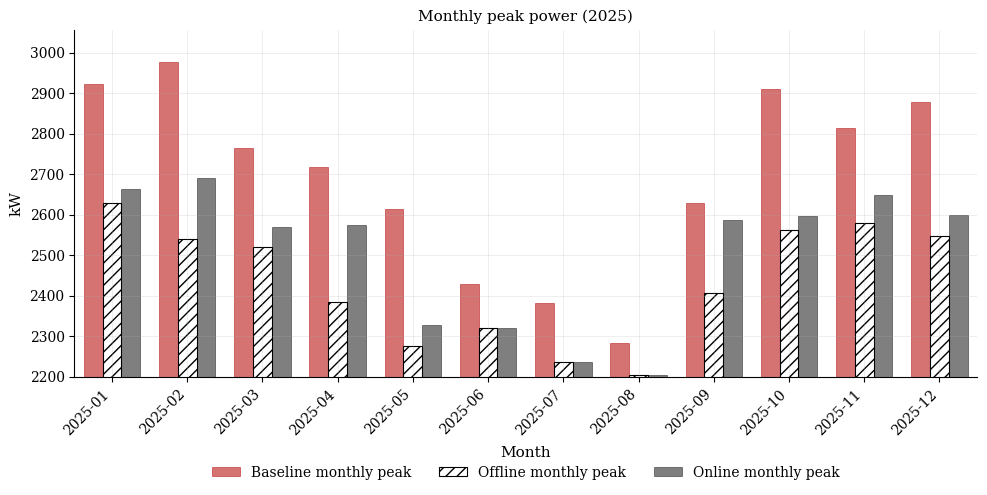

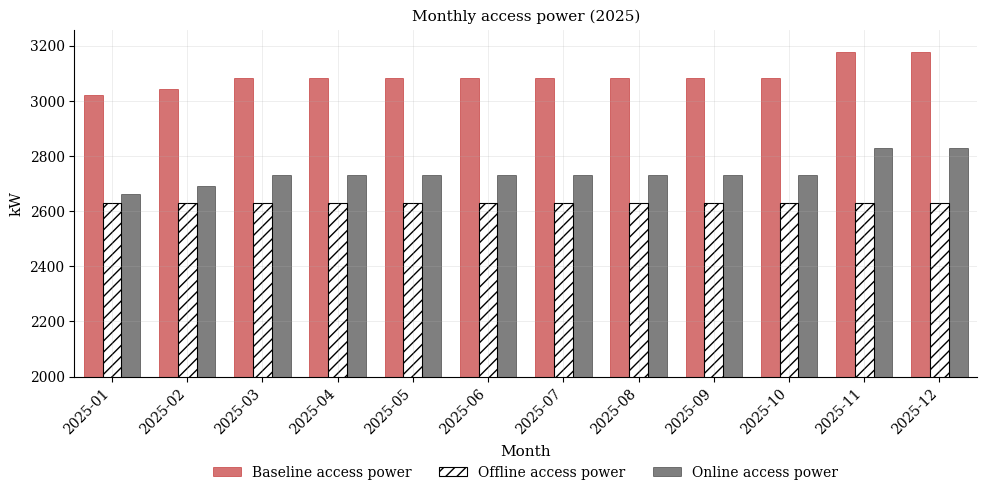

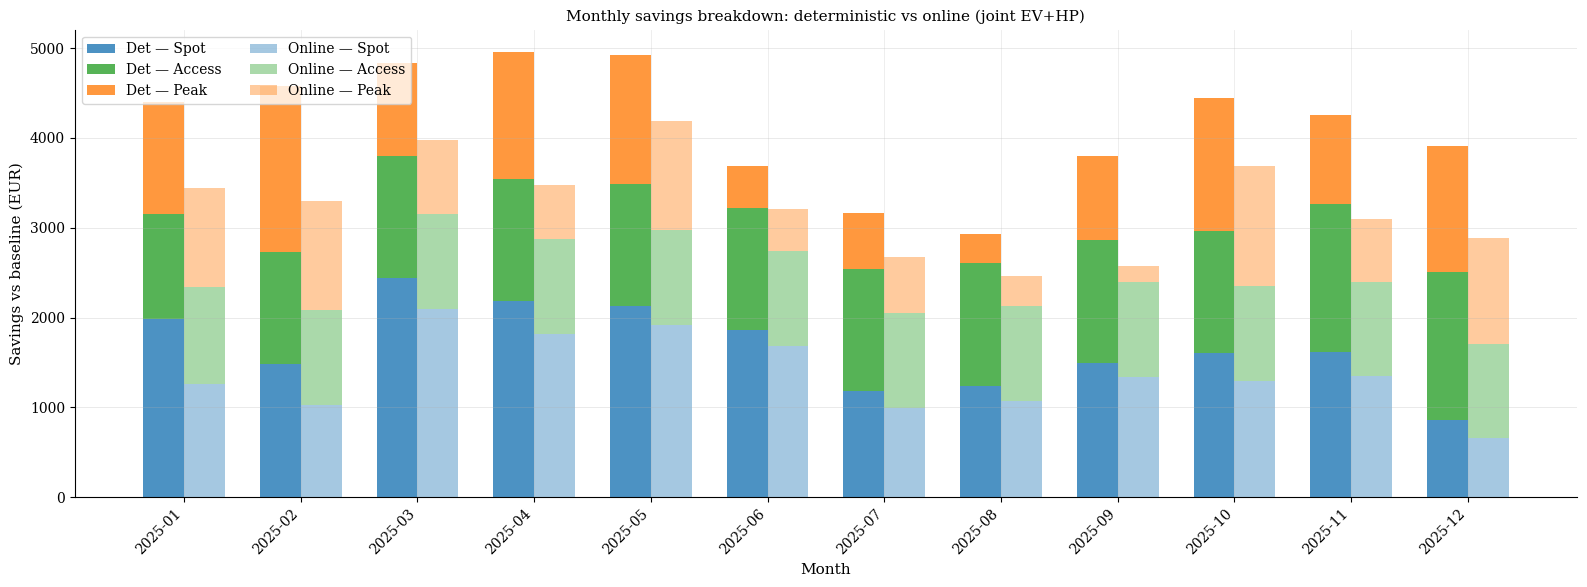


Savings breakdown (first rows):


,month,spot_savings_det,access_power_savings_det,peak_savings_det,total_savings_det,spot_savings_online,access_power_savings_online,peak_savings_online,total_savings_online
0,2025-01,1982.031834,1174.369584,1237.251497,4393.652915,1264.417327,1075.450572,1097.762263,3437.630162
1,2025-02,1487.886485,1237.318045,1848.665477,4573.870007,1030.694153,1055.966524,1212.510029,3299.170707
2,2025-03,2435.094309,1363.214969,1032.869390,4831.178668,2089.106887,1061.961616,826.297431,3977.365935
3,2025-04,2180.390663,1363.214969,1412.208002,4955.813634,1811.401888,1061.961616,605.716893,3479.080398
4,2025-05,2126.163791,1363.214969,1430.927803,4920.306564,1911.127045,1061.961616,1209.893301,4182.981963


In [13]:
# §3.2 — Shadow billing (baseline / deterministic joint / online)

import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

PROJECT_ROOT = Path("..").resolve()
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from billing import load_billing_config, calculate_monthly_bills, calculate_monthly_injection_bills

import importlib
import online_MPC_1_EV_HP_scenario_analysis as _evhp_scen_mod

importlib.reload(_evhp_scen_mod)

build_heating_charging_cost_table = _evhp_scen_mod.build_heating_charging_cost_table
compute_baseline_annual_net_cost_eur = _evhp_scen_mod.compute_baseline_annual_net_cost_eur
compute_deterministic_joint_annual_net_cost_eur = (
    _evhp_scen_mod.compute_deterministic_joint_annual_net_cost_eur
)
compute_nb01_site_reference_bills = _evhp_scen_mod.compute_nb01_site_reference_bills
compute_nb01_site_reference_annual_offtake_eur = (
    _evhp_scen_mod.compute_nb01_site_reference_annual_offtake_eur
)
compute_online_annual_net_cost_eur = _evhp_scen_mod.compute_online_annual_net_cost_eur

NOTEBOOKS_OUTPUT_DIR = PROJECT_ROOT / "output" / "notebooks"


def _load_monthly_exports(bills_global, inj_global, bills_path, inj_path):
    if bills_global in globals() and inj_global in globals():
        bills = globals()[bills_global].copy()
        inj = globals()[inj_global].copy()
    else:
        if not bills_path.exists() or not inj_path.exists():
            raise FileNotFoundError(
                f"Run notebook 04 export + §1.2 first.\n  {bills_path}\n  {inj_path}"
            )
        bills = pd.read_csv(bills_path)
        inj = pd.read_csv(inj_path)
    for _df in (bills, inj):
        if "month" in _df.columns:
            _df["month_key"] = _df["month"].astype(str)
    return bills, inj


base_bills, base_inj = _load_monthly_exports(
    "DET_EV_HP_MONTHLY_BASELINE_BILLS",
    "DET_EV_HP_MONTHLY_BASELINE_INJ",
    NOTEBOOKS_OUTPUT_DIR / "deterministic_ev_hp_monthly_baseline_bills_notebook_04.csv",
    NOTEBOOKS_OUTPUT_DIR / "deterministic_ev_hp_monthly_baseline_injection_notebook_04.csv",
)
det_bills, det_inj = _load_monthly_exports(
    "DET_EV_HP_MONTHLY_BILLS",
    "DET_EV_HP_MONTHLY_INJ",
    NOTEBOOKS_OUTPUT_DIR / "deterministic_ev_hp_monthly_bills_notebook_04.csv",
    NOTEBOOKS_OUTPUT_DIR / "deterministic_ev_hp_monthly_injection_notebook_04.csv",
)

if "table" not in globals():
    raise RuntimeError("Run §1.2 first to build `table`.")

_online_ap_mode = str(globals().get("ONLINE_ACCESS_POWER_MODE", "flex_aware"))
print(f"§3.2 — online scenario uses Part 2 access mode: {_online_ap_mode}")

# --- Online monthly bills (Part 2 summary or recompute) ---
if "summ_evhp_online" in globals() and isinstance(summ_evhp_online, dict):
    online_bills = summ_evhp_online["bills"].copy()
    online_inj = summ_evhp_online["injection_bills"].copy()
else:
    billing_cfg = load_billing_config(str(PROJECT_ROOT / "config" / "billing.yaml"))
    if "res_evhp_online" in globals():
        res_b = res_evhp_online.copy()
    else:
        _csv = NOTEBOOKS_OUTPUT_DIR / "online_ev_hp_15min_notebook_11_part2.csv"
        if not _csv.exists():
            raise FileNotFoundError(f"Run Part 2 first: {_csv}")
        res_b = pd.read_csv(_csv)
    res_b["timestamp"] = pd.to_datetime(res_b["timestamp"], errors="coerce")
    plant = pd.read_csv(PROJECT_ROOT / "data" / "plant1.csv")
    plant["timestamp"] = (
        pd.to_datetime(plant["timestamp"], utc=True, errors="coerce")
        .dt.tz_convert("Europe/Brussels")
        .dt.tz_localize(None)
    )
    plant = plant.sort_values("timestamp").reset_index(drop=True)
    plant = plant[
        (plant["timestamp"] >= pd.Timestamp("2025-01-01"))
        & (plant["timestamp"] < pd.Timestamp("2026-01-01"))
    ].copy()
    ev_col = "ev_applied" if "ev_applied" in res_b.columns else "ev_online_mpc"
    hp_col = "hp_applied" if "hp_applied" in res_b.columns else "hp_applied_kwh"
    plant_seq = plant[["timestamp", "inflex_load", "pv_production", "price"]].reset_index(drop=True)
    res_seq = res_b[[ev_col, hp_col, "access_kw"]].reset_index(drop=True)
    n = min(len(plant_seq), len(res_seq))
    if len(plant_seq) != len(res_seq):
        print(
            f"WARNING: plant vs online length mismatch; using n={n} "
            f"(plant={len(plant_seq)}, res={len(res_seq)})."
        )
    df_online = pd.concat([plant_seq.iloc[:n], res_seq.iloc[:n]], axis=1)
    net_kwh = (
        df_online["inflex_load"].fillna(0.0)
        + df_online[ev_col].fillna(0.0)
        + df_online[hp_col].fillna(0.0)
        - df_online["pv_production"].fillna(0.0)
    )
    df_online["grid_consumption"] = net_kwh.clip(lower=0.0)
    df_online["grid_injection"] = (-net_kwh).clip(lower=0.0)
    online_bills = calculate_monthly_bills(
        df_online,
        billing_cfg,
        volume_col="grid_consumption",
        price_col="price",
        timestamp_col="timestamp",
        access_power_col="access_kw",
    )
    online_inj = calculate_monthly_injection_bills(
        df_online,
        billing_cfg,
        injection_col="grid_injection",
        price_col="price",
        timestamp_col="timestamp",
    )

for _df in (online_bills, online_inj):
    if "month" in _df.columns:
        _df["month_key"] = _df["month"].astype(str)


def _net_monthly(bills, inj, net_col):
    out = bills[["month_key", "total_cost_eur"]].merge(
        inj[["month_key", "injection_net_revenue_eur"]], on="month_key", how="left"
    )
    out[net_col] = out["total_cost_eur"] - out["injection_net_revenue_eur"].fillna(0.0)
    return out


baseline_net_m = _net_monthly(base_bills, base_inj, "baseline_net_cost_eur")
det_net_m = _net_monthly(det_bills, det_inj, "deterministic_net_cost_eur")
online_net_m = _net_monthly(online_bills, online_inj, "online_net_cost_eur")

months = sorted(
    set(base_bills["month_key"]) | set(det_bills["month_key"]) | set(online_bills["month_key"])
)
shadow = pd.DataFrame({"month_key": months}).set_index("month_key")
shadow["baseline_net_cost_eur"] = (
    baseline_net_m.set_index("month_key")["baseline_net_cost_eur"].reindex(shadow.index).values
)
shadow["deterministic_net_cost_eur"] = (
    det_net_m.set_index("month_key")["deterministic_net_cost_eur"].reindex(shadow.index).values
)
shadow["online_net_cost_eur"] = (
    online_net_m.set_index("month_key")["online_net_cost_eur"].reindex(shadow.index).values
)
shadow["deterministic_savings_eur"] = (
    shadow["baseline_net_cost_eur"] - shadow["deterministic_net_cost_eur"]
)
shadow["online_savings_eur"] = shadow["baseline_net_cost_eur"] - shadow["online_net_cost_eur"]

shadow_billing_evhp = shadow.reset_index().rename(columns={"month_key": "month"})

print("Shadow billing monthly comparison (joint EV+HP)")
display(
    shadow_billing_evhp[
        [
            "month",
            "baseline_net_cost_eur",
            "deterministic_net_cost_eur",
            "online_net_cost_eur",
            "deterministic_savings_eur",
            "online_savings_eur",
        ]
    ]
)

def _net_total(bills, inj):
    return float(bills["total_cost_eur"].sum() - inj["injection_net_revenue_eur"].sum())


baseline_total = _net_total(base_bills, base_inj)
deterministic_total = _net_total(det_bills, det_inj)
online_total = _net_total(online_bills, online_inj)

print("\n" + "=" * 80)
print("COST COMPARISON: BASELINE vs DETERMINISTIC vs ONLINE MPC (joint EV+HP)")
print("=" * 80)
print(
    f"\n{'Cost Component':<30} "
    f"{'Baseline (EUR)':>20} {'Deterministic (EUR)':>20} {'Online (EUR)':>20} "
    f"{'Savings det (EUR)':>20} {'Savings online (EUR)':>22}"
)
print("-" * 132)

rows = [
    (
        "Energy Cost",
        base_bills["energy_cost_eur"].sum(),
        det_bills["energy_cost_eur"].sum(),
        online_bills["energy_cost_eur"].sum(),
    ),
    (
        "Spot Cost",
        base_bills["spot_cost_eur"].sum(),
        det_bills["spot_cost_eur"].sum(),
        online_bills["spot_cost_eur"].sum(),
    ),
    (
        "Access Power Cost",
        base_bills["access_cost_eur"].sum(),
        det_bills["access_cost_eur"].sum(),
        online_bills["access_cost_eur"].sum(),
    ),
    (
        "Monthly Peak Cost",
        base_bills["monthly_peak_cost_eur"].sum(),
        det_bills["monthly_peak_cost_eur"].sum(),
        online_bills["monthly_peak_cost_eur"].sum(),
    ),
    (
        "Over-usage Cost",
        base_bills["over_usage_cost_eur"].sum(),
        det_bills["over_usage_cost_eur"].sum(),
        online_bills["over_usage_cost_eur"].sum(),
    ),
    (
        "Injection Revenue",
        -base_inj["injection_net_revenue_eur"].sum(),
        -det_inj["injection_net_revenue_eur"].sum(),
        -online_inj["injection_net_revenue_eur"].sum(),
    ),
]
for name, b, d, o in rows:
    print(
        f"{name:<30} "
        f"{b:>20,.2f} {d:>20,.2f} {o:>20,.2f} "
        f"{b - d:>20,.2f} {b - o:>22,.2f}"
    )

print("-" * 132)
print(
    f"{'NET TOTAL':<30} "
    f"{baseline_total:>20,.2f} {deterministic_total:>20,.2f} {online_total:>20,.2f} "
    f"{baseline_total - deterministic_total:>20,.2f} {baseline_total - online_total:>22,.2f}"
)
print("=" * 80)

savings_det = baseline_total - deterministic_total
savings_online = baseline_total - online_total
if baseline_total > 0:
    print(
        f"Savings vs baseline — deterministic: {savings_det:,.2f} EUR "
        f"({100.0 * savings_det / baseline_total:.2f}%)"
    )
    print(
        f"Savings vs baseline — online:       {savings_online:,.2f} EUR "
        f"({100.0 * savings_online / baseline_total:.2f}%)"
    )

nb01_site_bills, nb01_site_inj = compute_nb01_site_reference_bills(PROJECT_ROOT)
site_ref_eur = float(nb01_site_bills["total_cost_eur"].sum())
_nb01_check = compute_nb01_site_reference_annual_offtake_eur(PROJECT_ROOT)
assert abs(site_ref_eur - _nb01_check) < 0.01

flex_cost_table = build_heating_charging_cost_table(
    baseline_net_eur=baseline_total,
    offline_net_eur=deterministic_total,
    online_net_eur=online_total,
    inflex_site_net_eur=site_ref_eur,
)
heating_charging_cost_evhp = flex_cost_table.copy()

print("\n" + "=" * 80)
print("HEATING & CHARGING COST — incremental over notebook 01 site reference")
print("=" * 80)
print(
    "Reference R: grid_consumption_excl_ev (no EV on meter), conservative access "
    "from full-site grid_consumption peaks (notebook 01 EV billing section)."
)
print(f"Notebook 01 site offtake total_cost_eur: {site_ref_eur:,.2f} EUR")
print(
    "Heating & charging cost = full annual net − R  (EV + HP flex loads, all tariff components)."
)
if _online_ap_mode == "deterministic":
    print(
        "Online column: selected scenario MPC with Online AP (deterministic access); "
        "Offline column: deterministic joint export (notebook 04)."
    )
else:
    print(
        "Online column: selected scenario MPC with Offline AP (flex-aware access); "
        "Offline column: deterministic joint export (notebook 04)."
    )
display(flex_cost_table.style.format("{:,.2f}"))

flex_baseline = float(flex_cost_table.loc["Heating & charging cost [EUR]", "Baseline (uncontrolled)"])
flex_offline = float(flex_cost_table.loc["Heating & charging cost [EUR]", "Offline (deterministic joint)"])
flex_online = float(flex_cost_table.loc["Heating & charging cost [EUR]", "Online (scenario MPC)"])
print(
    f"\nFlex-load savings vs baseline — offline: {flex_baseline - flex_offline:,.2f} EUR; "
    f"online: {flex_baseline - flex_online:,.2f} EUR"
)
print("=" * 80)
if "res_evhp_online" in globals():
    _res_chk = res_evhp_online
elif (NOTEBOOKS_OUTPUT_DIR / "online_ev_hp_15min_notebook_11_part2.csv").exists():
    _res_chk = pd.read_csv(NOTEBOOKS_OUTPUT_DIR / "online_ev_hp_15min_notebook_11_part2.csv")
else:
    _res_chk = None
if _res_chk is not None:
    print("\nAnnual net cost cross-check (helpers):")
    baseline_access = ACCESS_POWER_BASELINE_MONTHLY.astype(float).to_dict()
    print(f"  Baseline:       {compute_baseline_annual_net_cost_eur(PROJECT_ROOT, baseline_access):,.0f} EUR")
    print(
        f"  Deterministic:  "
        f"{compute_deterministic_joint_annual_net_cost_eur(PROJECT_ROOT, None):,.0f} EUR"
    )
    print(f"  Online:         {compute_online_annual_net_cost_eur(PROJECT_ROOT, _res_chk):,.0f} EUR")

baseline_net = baseline_total
det_net = deterministic_total
online_net = online_total

base_idx = base_bills.set_index("month_key")
det_idx = det_bills.set_index("month_key")
on_idx = online_bills.set_index("month_key")
months_plot = shadow_billing_evhp["month"].astype(str).tolist()
x = np.arange(len(months_plot))
width = 0.25

import matplotlib as mpl

THESIS_STYLE = {
    "font.family": "serif",
    "font.size": 11,
    "axes.labelsize": 11,
    "axes.titlesize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.linewidth": 0.8,
    "text.color": "black",
    "axes.labelcolor": "black",
    "xtick.color": "black",
    "ytick.color": "black",
    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linewidth": 0.6,
    "lines.linewidth": 2.2,
    "savefig.dpi": 300,
}
mpl.rcParams.update(THESIS_STYLE)
C_BLACK = "#000000"
C_KUL_RED = "#b30000"

_peak_base = base_idx.reindex(months_plot)["monthly_peak_kw"].values.astype(float)
_peak_off = det_idx.reindex(months_plot)["monthly_peak_kw"].values.astype(float)
_peak_on = on_idx.reindex(months_plot)["monthly_peak_kw"].values.astype(float)

fig_peak, ax_peak = plt.subplots(figsize=(10, 5))
mpl.rcParams["hatch.color"] = C_BLACK
ax_peak.bar(
    x - width,
    _peak_base,
    width,
    label="Baseline monthly peak",
    color=C_KUL_RED,
    alpha=0.55,
    edgecolor=C_KUL_RED,
    linewidth=0.6,
)
ax_peak.bar(
    x,
    _peak_off,
    width,
    label="Offline monthly peak",
    facecolor="white",
    edgecolor=C_BLACK,
    hatch="///",
    linewidth=0.8,
)
ax_peak.bar(
    x + width,
    _peak_on,
    width,
    label="Online monthly peak",
    color=C_BLACK,
    alpha=0.5,
    edgecolor=C_BLACK,
    linewidth=0.6,
)
ax_peak.set_ylabel("kW")
_peak_ymax = float(np.nanmax([_peak_base, _peak_off, _peak_on]))
ax_peak.set_ylim(2200, max(3000.0, _peak_ymax + 80.0))
ax_peak.set_title("Monthly peak power (2025)")
ax_peak.set_xticks(x)
ax_peak.set_xticklabels(months_plot, rotation=45, ha="right")
ax_peak.set_xlim(-0.5, len(months_plot) - 0.5)
ax_peak.margins(x=0)
ax_peak.tick_params(axis="x", pad=4)
ax_peak.set_xlabel("Month", labelpad=6)
_peak_handles, _peak_labels = ax_peak.get_legend_handles_labels()
ax_peak.legend(
    _peak_handles,
    _peak_labels,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.22),
    ncol=3,
    frameon=False,
)
fig_peak.subplots_adjust(bottom=0.28, top=0.90)
plt.tight_layout()
plt.show()

fig_acc_cmp, ax2 = plt.subplots(figsize=(10, 5))
# `table` is indexed by month; access powers are columns (see §1.2)
_cons = table["access_power_conservative"].astype(float)
ax2.bar(
    x - width,
    _cons.reindex(months_plot).values,
    width,
    label="Baseline access power",
    color=C_KUL_RED,
    alpha=0.55,
    edgecolor=C_KUL_RED,
    linewidth=0.6,
)
ax2.bar(
    x,
    det_idx.reindex(months_plot)["access_power_kw"].values,
    width,
    label="Offline access power",
    facecolor="white",
    edgecolor=C_BLACK,
    hatch="///",
    linewidth=0.8,
)
ax2.bar(
    x + width,
    on_idx.reindex(months_plot)["access_power_kw"].values,
    width,
    label="Online access power",
    color=C_BLACK,
    alpha=0.5,
    edgecolor=C_BLACK,
    linewidth=0.6,
)
ax2.set_ylabel("kW")
_acc_ymax = float(
    np.nanmax(
        [
            _cons.reindex(months_plot).values,
            det_idx.reindex(months_plot)["access_power_kw"].values,
            on_idx.reindex(months_plot)["access_power_kw"].values,
        ]
    )
)
ax2.set_ylim(2000, max(3200.0, _acc_ymax + 80.0))
ax2.set_title("Monthly access power (2025)")
ax2.set_xticks(x)
ax2.set_xticklabels(months_plot, rotation=45, ha="right")
ax2.set_xlim(-0.5, len(months_plot) - 0.5)
ax2.margins(x=0)
ax2.set_xlabel("Month", labelpad=6)
_acc_handles, _acc_labels = ax2.get_legend_handles_labels()
ax2.legend(
    _acc_handles,
    _acc_labels,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.22),
    ncol=3,
    frameon=False,
)
fig_acc_cmp.subplots_adjust(bottom=0.28, top=0.90)
plt.tight_layout()
plt.show()

base_spot = base_idx.reindex(months_plot)["spot_cost_eur"].values
base_access = base_idx.reindex(months_plot)["access_cost_eur"].values
base_peak = (
    base_idx.reindex(months_plot)["monthly_peak_cost_eur"].values
    + base_idx.reindex(months_plot)["over_usage_cost_eur"].values
)
det_spot = det_idx.reindex(months_plot)["spot_cost_eur"].values
det_access = det_idx.reindex(months_plot)["access_cost_eur"].values
det_peak = (
    det_idx.reindex(months_plot)["monthly_peak_cost_eur"].values
    + det_idx.reindex(months_plot)["over_usage_cost_eur"].values
)
on_spot = on_idx.reindex(months_plot)["spot_cost_eur"].values
on_access = on_idx.reindex(months_plot)["access_cost_eur"].values
on_peak = (
    on_idx.reindex(months_plot)["monthly_peak_cost_eur"].values
    + on_idx.reindex(months_plot)["over_usage_cost_eur"].values
)

savings = pd.DataFrame(
    {
        "month": months_plot,
        "spot_savings_det": base_spot - det_spot,
        "access_power_savings_det": base_access - det_access,
        "peak_savings_det": base_peak - det_peak,
        "spot_savings_online": base_spot - on_spot,
        "access_power_savings_online": base_access - on_access,
        "peak_savings_online": base_peak - on_peak,
    }
)
savings["total_savings_det"] = savings[
    ["spot_savings_det", "access_power_savings_det", "peak_savings_det"]
].sum(axis=1)
savings["total_savings_online"] = savings[
    ["spot_savings_online", "access_power_savings_online", "peak_savings_online"]
].sum(axis=1)

fig, ax = plt.subplots(figsize=(16, 6))
w = 0.35
ax.bar(x - w / 2, savings["spot_savings_det"], w, label="Det — Spot", color="tab:blue", alpha=0.8)
ax.bar(
    x - w / 2,
    savings["access_power_savings_det"],
    w,
    bottom=savings["spot_savings_det"],
    label="Det — Access",
    color="tab:green",
    alpha=0.8,
)
ax.bar(
    x - w / 2,
    savings["peak_savings_det"],
    w,
    bottom=savings["spot_savings_det"] + savings["access_power_savings_det"],
    label="Det — Peak",
    color="tab:orange",
    alpha=0.8,
)
ax.bar(x + w / 2, savings["spot_savings_online"], w, label="Online — Spot", color="tab:blue", alpha=0.4)
ax.bar(
    x + w / 2,
    savings["access_power_savings_online"],
    w,
    bottom=savings["spot_savings_online"],
    label="Online — Access",
    color="tab:green",
    alpha=0.4,
)
ax.bar(
    x + w / 2,
    savings["peak_savings_online"],
    w,
    bottom=savings["spot_savings_online"] + savings["access_power_savings_online"],
    label="Online — Peak",
    color="tab:orange",
    alpha=0.4,
)
ax.set_xlabel("Month")
ax.set_ylabel("Savings vs baseline (EUR)")
ax.set_title("Monthly savings breakdown: deterministic vs online (joint EV+HP)")
ax.set_xticks(x)
ax.set_xticklabels(savings["month"], rotation=45, ha="right")
ax.legend(loc="upper left", ncol=2)
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

print("\nSavings breakdown (first rows):")
display(
    savings[
        [
            "month",
            "spot_savings_det",
            "access_power_savings_det",
            "peak_savings_det",
            "total_savings_det",
            "spot_savings_online",
            "access_power_savings_online",
            "peak_savings_online",
            "total_savings_online",
        ]
    ].head()
)


## 4. Scenario analysis

Batch joint EV+HP online MPC over **12 scenarios** (Part 2 defaults + grid):

| Axis | Values |
|------|--------|
| Access contract | `flex_aware`, `deterministic` (§1.2 dicts) |
| SOC floor strength | `0.5`, `0.75`, `1.0` |
| Inflex forecast (regular) | `p50`, `p90` (`c_p50`, `c_p90`; stress quantile fixed at Part 2) |

| Part | Purpose | Access power |
|------|---------|----------------|
| **4A** | Define `SCENARIOS` (`EvHpOnlineScenario`) | — |
| **4B** | Full-year MPC per scenario (`RUN_SCENARIOS`) | Per scenario: flex or det |
| **4C** | Viewer: Part 3.1 + 3.2 for one export | From scenario CSV `access_kw` |
| **4D** | Stacked savings vs baseline (all scenarios) | Baseline: §1.2 conservative; online: each CSV |

**Prerequisites:** §1.2 (`ACCESS_POWER_FLEX_DICT`, `ACCESS_POWER_DETERMINISTIC_DICT`, `ACCESS_POWER_BASELINE_MONTHLY`), notebook 04 exports, Part 2 forecast CSVs.

**Run order:** §1.2 → Part 2 (optional reference) → set `RUN_SCENARIOS=True` in 4B only when recomputing → 4C–4D.

**Outputs:** `online_ev_hp_15min_notebook_11_scenario_*.csv`, `online_ev_hp_scenario_analysis_summary_notebook_11.csv`.


### 4A — Scenario definitions


In [3]:
# Part 4A — Scenario definitions (12 scenarios; Part 2 defaults + grid)

import importlib
import sys
from pathlib import Path

import pandas as pd

PROJECT_ROOT = Path("..").resolve()
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

import online_MPC_1_EV_HP_scenario_analysis as _evhp_sa

importlib.reload(_evhp_sa)
from online_MPC_1_EV_HP_scenario_analysis import EvHpOnlineScenario

if "access_power_mode" not in EvHpOnlineScenario.__dataclass_fields__:
    raise RuntimeError(
        "Stale online_MPC_1_EV_HP_scenario_analysis — restart kernel or check src/ was saved."
    )

# Part 2 defaults (fixed for all scenarios; regular inflex quantile is swept in the loop)
BASE_COMMON = dict(
    forecast_strategy_ev="c_p90",
    forecast_strategy_pv="chronos2_elia_p50",
    forecast_strategy_thermal="c2t_p50",
    forecast_strategy_temperature="open_meteo_day_ahead",
    forecast_strategy_inflex_stress="c_p99",
    ev_deadline_slack_minutes=105,
    enforce_daily_ev_demand=True,
    enforce_soc_min=True,
    enforce_soc_max=True,
    monthly_peak_price_multiplier=1.0,
    horizon_len=96,
    enable_forecast_stress_soc_floor=True,
)

ACCESS_MODES = ["flex_aware", "deterministic"]
SOC_FLOOR_STRENGTHS = [0.5, 0.75, 1.0]
INFLEX_FORECAST_QUANTILES = ["p50", "p90"]

SCENARIOS: list[EvHpOnlineScenario] = []
for access_mode in ACCESS_MODES:
    access_tag = "flex" if access_mode == "flex_aware" else "det"
    for strength in SOC_FLOOR_STRENGTHS:
        floor_tag = str(strength).replace(".", "p")
        for q in INFLEX_FORECAST_QUANTILES:
            SCENARIOS.append(
                EvHpOnlineScenario(
                    scenario_id=len(SCENARIOS) + 1,
                    name=f"access_{access_tag}_inflex_{q}_floor_{floor_tag}",
                    access_power_mode=access_mode,
                    forecast_strategy_inflex=f"c_{q}",
                    forecast_stress_soc_floor_strength=strength,
                    **BASE_COMMON,
                )
            )

assert len({s.scenario_id for s in SCENARIOS}) == len(SCENARIOS)
assert len(SCENARIOS) == 12
print(f"Defined {len(SCENARIOS)} scenarios (expected 12)")
pd.DataFrame(
    [
        {
            "scenario_id": s.scenario_id,
            "name": s.name,
            "access_power_mode": s.access_power_mode,
            "inflex_forecast": s.forecast_strategy_inflex,
            "inflex_stress": s.forecast_strategy_inflex_stress,
            "floor_strength": s.forecast_stress_soc_floor_strength,
        }
        for s in SCENARIOS
    ]
)


Defined 12 scenarios (expected 12)


,scenario_id,name,access_power_mode,inflex_forecast,inflex_stress,floor_strength
0,1,access_flex_inflex_p50_floor_0p5,flex_aware,c_p50,c_p99,0.50
1,2,access_flex_inflex_p90_floor_0p5,flex_aware,c_p90,c_p99,0.50
2,3,access_flex_inflex_p50_floor_0p75,flex_aware,c_p50,c_p99,0.75
3,4,access_flex_inflex_p90_floor_0p75,flex_aware,c_p90,c_p99,0.75
4,5,access_flex_inflex_p50_floor_1p0,flex_aware,c_p50,c_p99,1.00
5,6,access_flex_inflex_p90_floor_1p0,flex_aware,c_p90,c_p99,1.00
6,7,access_det_inflex_p50_floor_0p5,deterministic,c_p50,c_p99,0.50
7,8,access_det_inflex_p90_floor_0p5,deterministic,c_p90,c_p99,0.50
8,9,access_det_inflex_p50_floor_0p75,deterministic,c_p50,c_p99,0.75
9,10,access_det_inflex_p90_floor_0p75,deterministic,c_p90,c_p99,0.75


### 4B — Batch run


In [ ]:
# Part 4B — Run all scenarios (full-year × 12; long run)

import importlib
import sys
from pathlib import Path

PROJECT_ROOT = Path("..").resolve()
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

NOTEBOOKS_OUTPUT_DIR = PROJECT_ROOT / "output" / "notebooks"

import online_MPC_1_EV_HP
import online_MPC_1_EV_HP_scenario_analysis as _evhp_sa

importlib.reload(online_MPC_1_EV_HP)
importlib.reload(_evhp_sa)
from online_MPC_1_EV_HP_scenario_analysis import run_ev_hp_online_scenario_analysis

RUN_SCENARIOS = False  # set True to recompute batch

if RUN_SCENARIOS:
    for _name in (
        "ACCESS_POWER_FLEX_DICT",
        "ACCESS_POWER_DETERMINISTIC_DICT",
        "ACCESS_POWER_BASELINE_MONTHLY",
    ):
        if _name not in globals():
            raise RuntimeError(f"Run §1.2 first (missing {_name}).")
    EVHP_SCENARIO_OUT = run_ev_hp_online_scenario_analysis(
        scenarios=SCENARIOS,
        access_power_flex_by_month=ACCESS_POWER_FLEX_DICT,
        access_power_deterministic_by_month=ACCESS_POWER_DETERMINISTIC_DICT,
        baseline_access_power_by_month=ACCESS_POWER_BASELINE_MONTHLY.astype(float).to_dict(),
        out_dir=NOTEBOOKS_OUTPUT_DIR,
        verbose=True,
        mpc_verbose=True,
    )
    print("Master summary:", EVHP_SCENARIO_OUT.master_summary_path)
else:
    _summary = NOTEBOOKS_OUTPUT_DIR / "online_ev_hp_scenario_analysis_summary_notebook_11.csv"
    if _summary.exists():
        print(f"Skipping batch (RUN_SCENARIOS=False). Existing summary: {_summary}")
    else:
        print("Skipping batch (RUN_SCENARIOS=False). No summary CSV yet — set RUN_SCENARIOS=True after §1.2.")


### 4C — Viewer (Part 3.1 + 3.2)


Wrote summary JSON: online_ev_hp_summary_notebook_11_scenario_01_access_flex_inflex_p50_floor_0p5.json
Part 4C — online_ev_hp_15min_notebook_11_scenario_01_access_flex_inflex_p50_floor_0p5.csv (access: flex_aware)
§3.1 plot window: week 2025-02-10 – 2025-02-16, daily day 2 -> 2025-02-11

SOC violations summary (online MPC (soc_after))
SOC bounds: [0.200, 0.950]
Violation points: 225 (each = 15 min)
Violation episodes: 222
Total violated time: 56.25 h; max episode: 0.50 h

SOC violations summary (deterministic MPC (buffer_soc))
SOC bounds: [0.200, 0.950]
Violation points: 0 (each = 15 min)
Violation episodes: 0


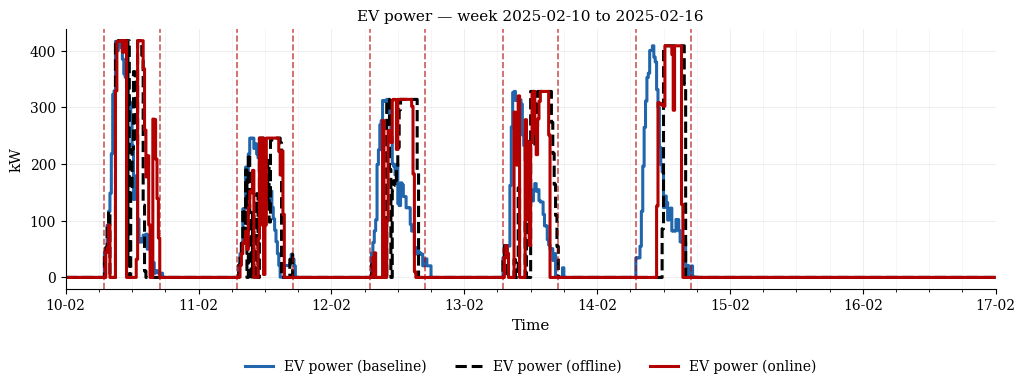

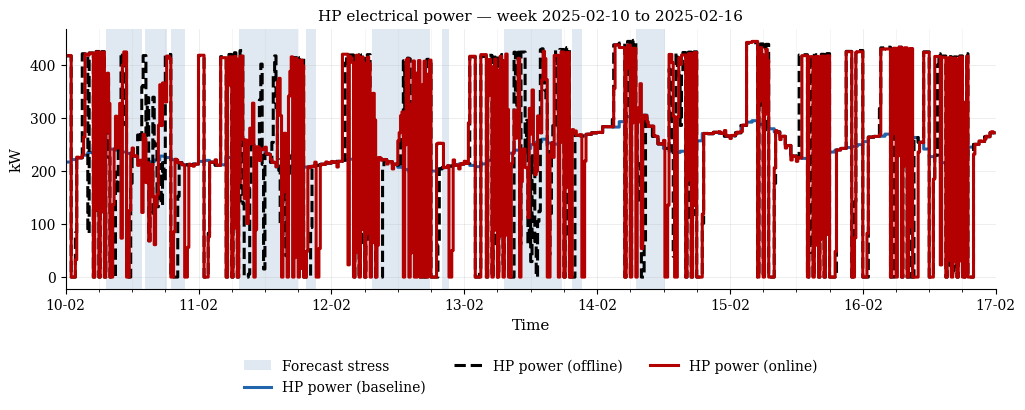

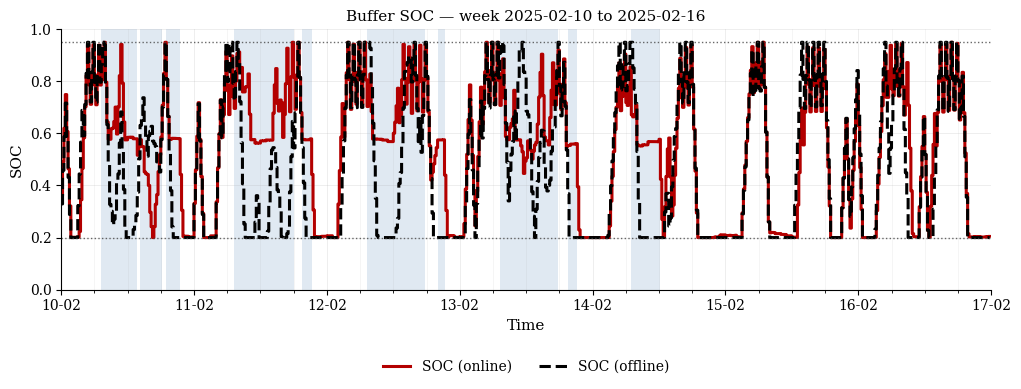

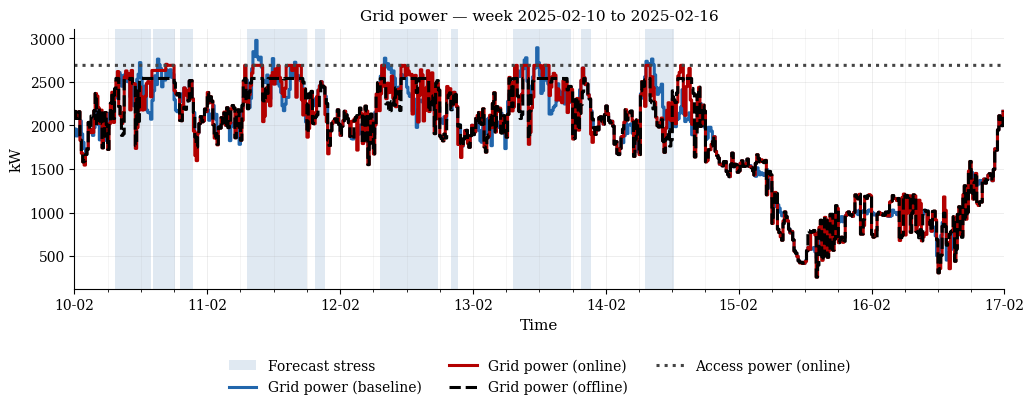

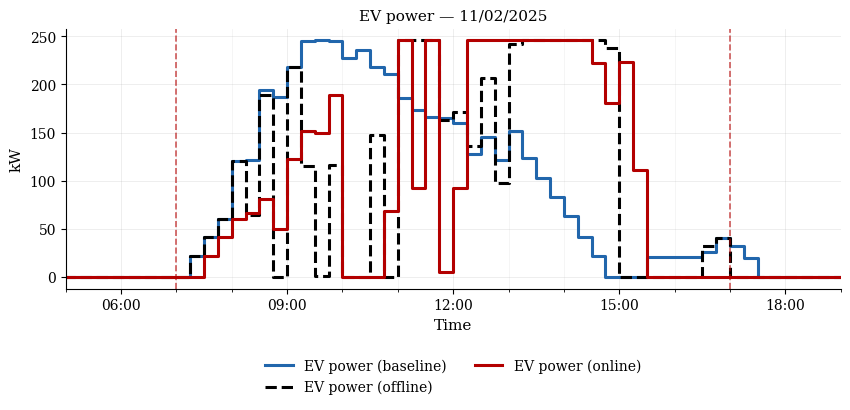

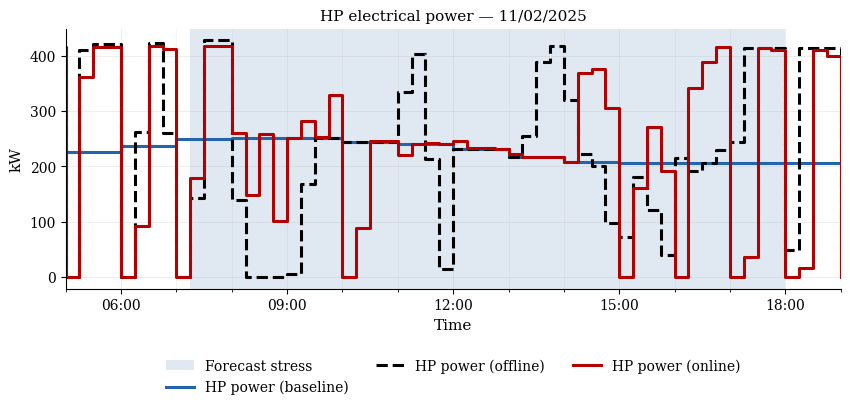

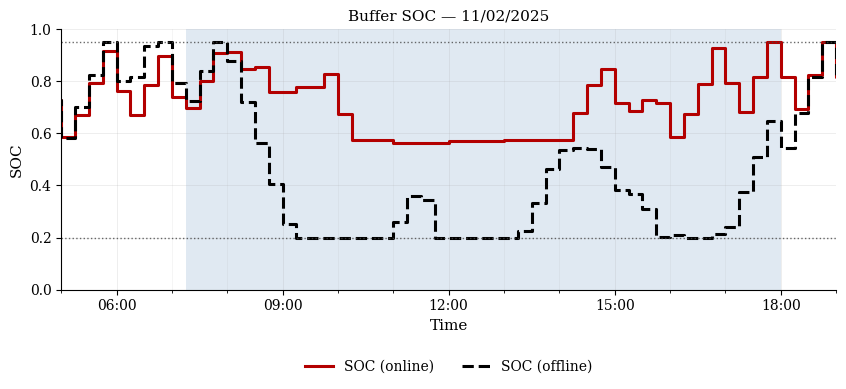

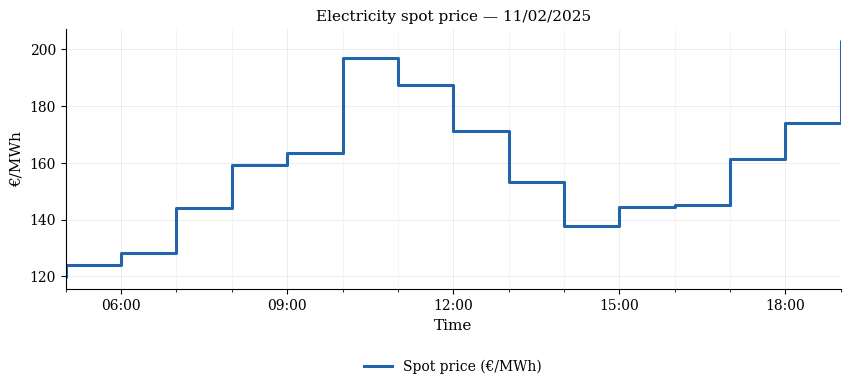

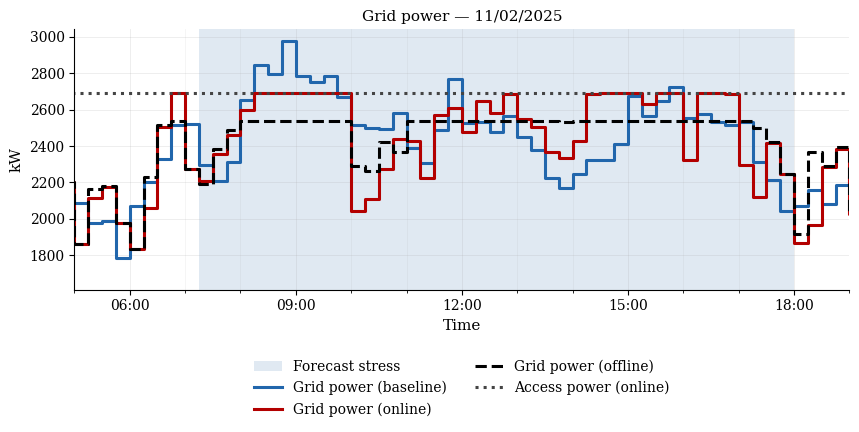


Day replay — 2025-02-11  (slack 105 min → MPC ends 15:15)
Grid peak 2690.0 kW | access 2690.0 kW | p_limit [2690.0, 2690.0] kW
Access violations: 0 steps, max exceed 0.0 kW
EV delivered 1158.4 kWh (MPC region 1130.6, catch-up 27.8)
Enforce: 0 active steps, 0.0 kWh extra | Deferred: 3 steps
EV still to deliver at MPC region end: 83.5 kWh
Catch-up max access exceed: 0.0 kW
Mechanism: p_limit ≈ min(access, max(peak_so_far, monthly_peak_plan)) in MPC region; low monthly_peak_plan holds clip below access until catch-up enforce pushes EV.


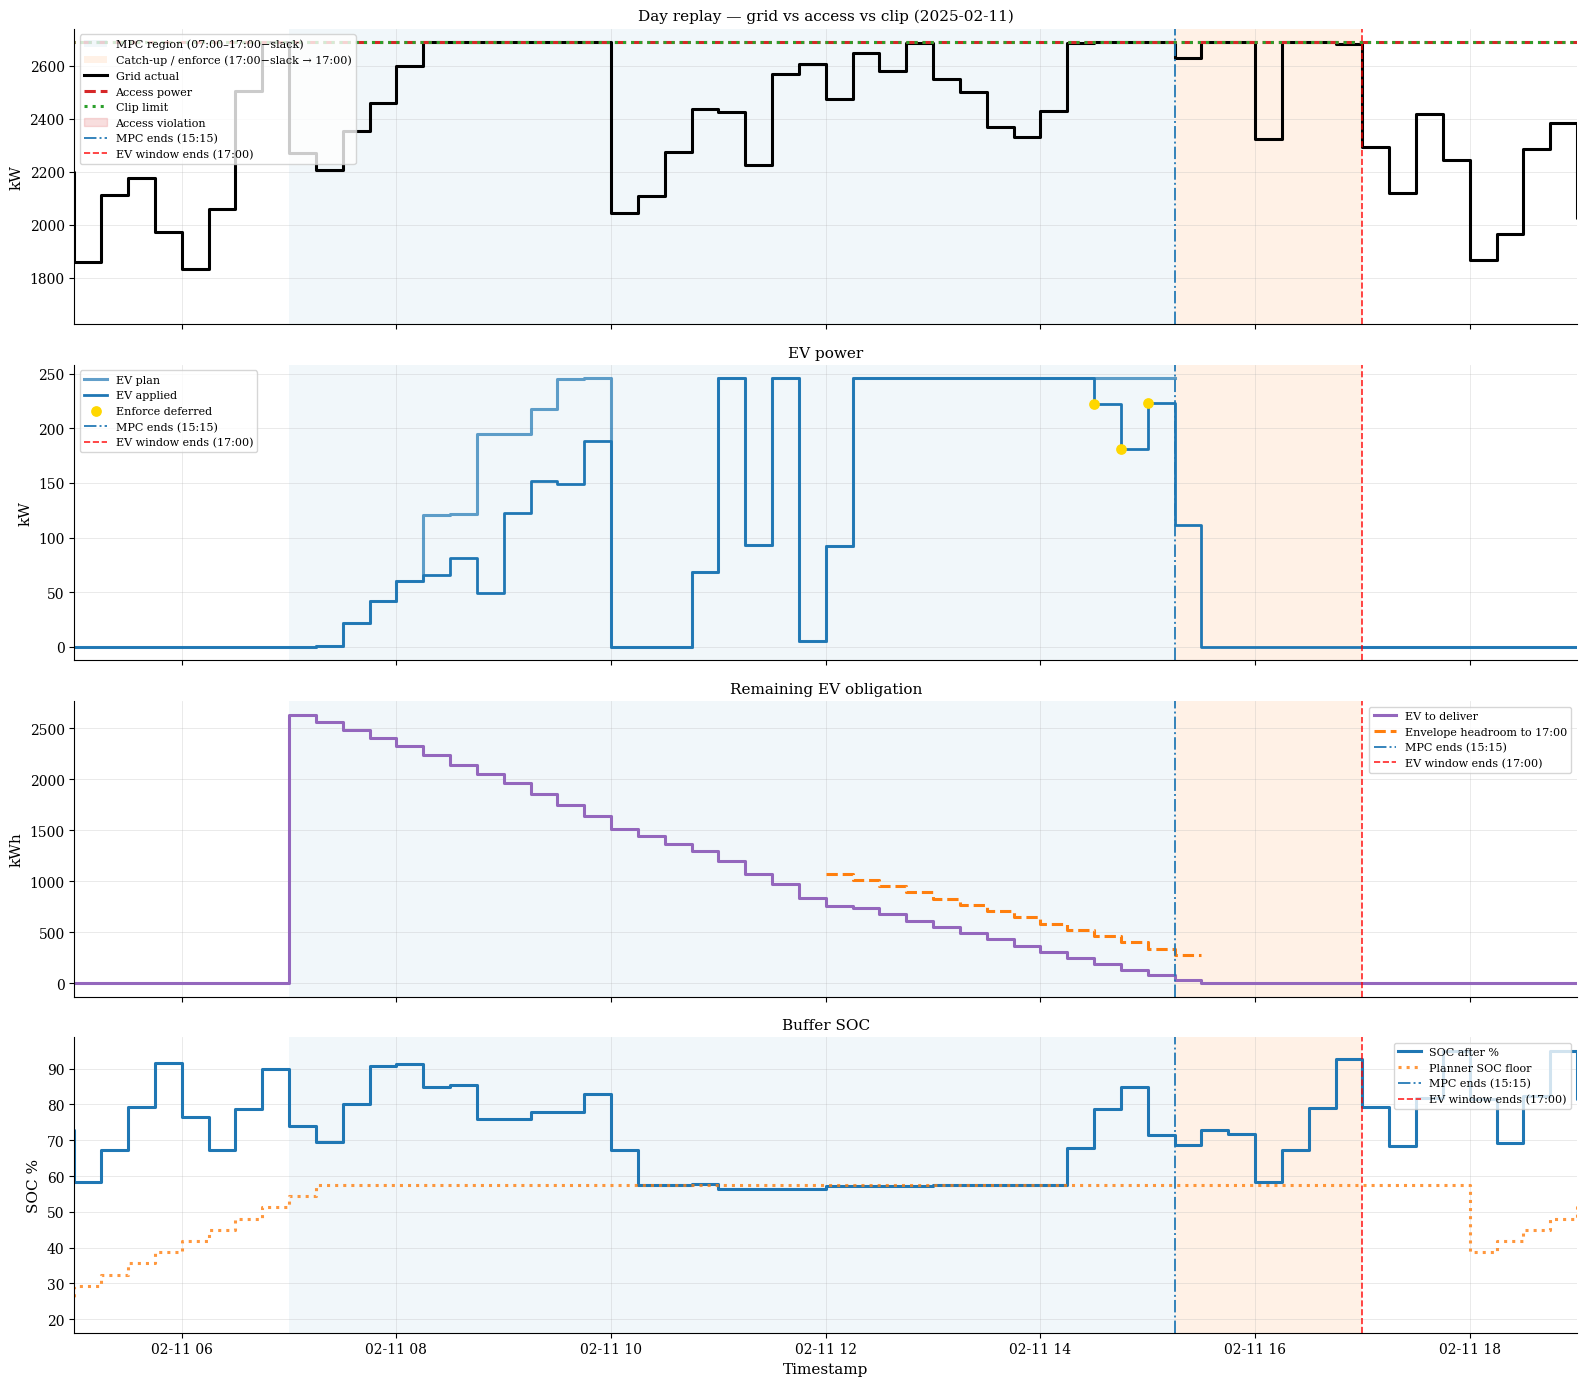


Day summary (2025-02-11): EV online 1158.4 kWh, HP online 5314.8 kWh, mean SOC 58.0%, enforce active 0 steps, deferred 3 steps


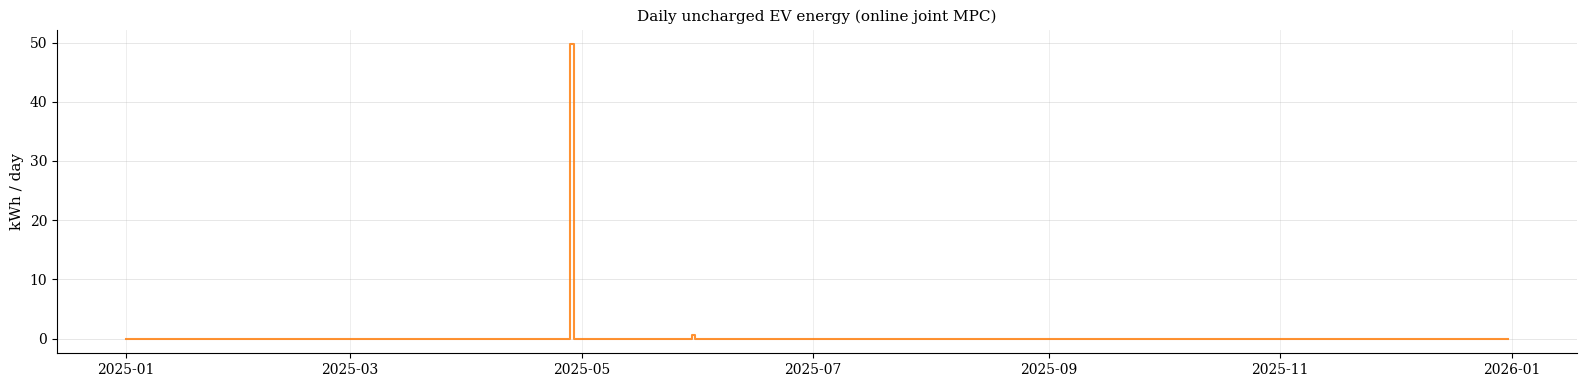

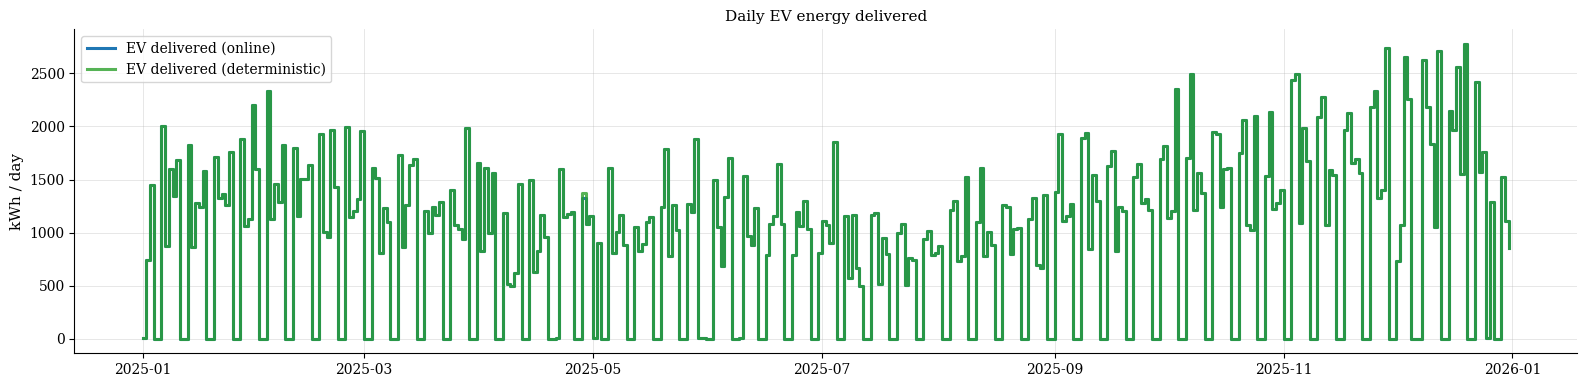

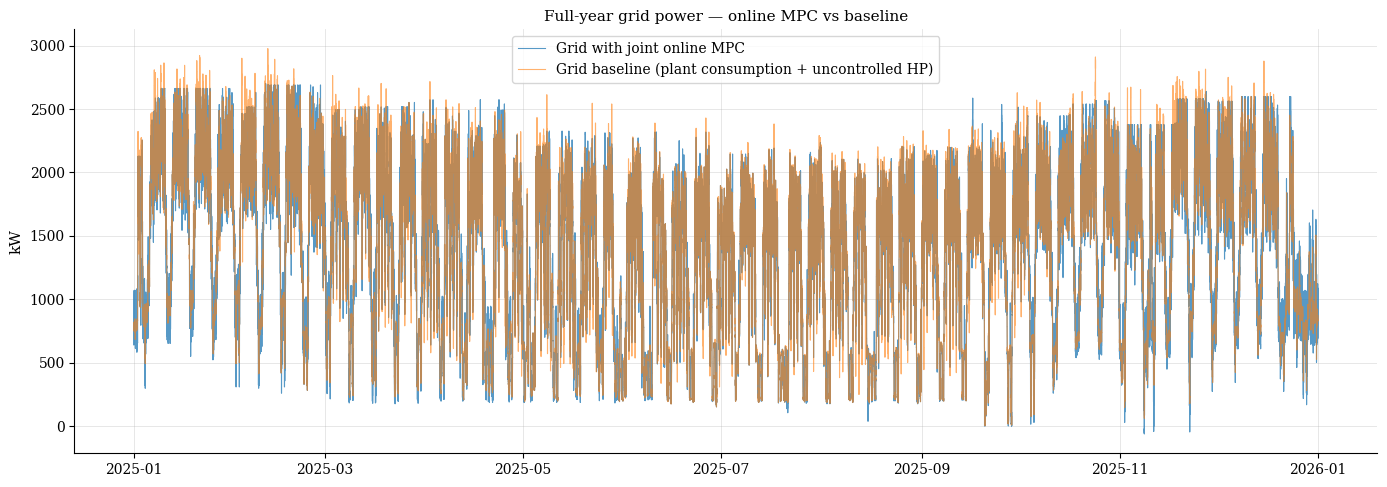


MPC 24h window debug skipped (RUN_MPC_DEBUG=False).
§3.2 — online scenario uses Part 2 access mode: flex_aware
Shadow billing monthly comparison (joint EV+HP)


,month,baseline_net_cost_eur,deterministic_net_cost_eur,online_net_cost_eur,deterministic_savings_eur,online_savings_eur
0,2025-01,222371.305704,217925.754070,218707.118662,4445.551634,3664.187042
1,2025-02,218999.166325,214398.692533,215631.077776,4600.473792,3368.088548
2,2025-03,173724.065480,168770.354191,169520.757619,4953.711289,4203.307862
3,2025-04,137313.014435,132398.580042,133863.059558,4914.434393,3449.954877
4,2025-05,113112.673032,108159.913038,108937.721735,4952.759994,4174.951297
5,2025-06,111002.345971,107208.629381,107741.426802,3793.716590,3260.919169
6,2025-07,127639.270506,124440.449911,124992.907790,3198.820596,2646.362717
7,2025-08,113366.230398,110417.062790,110946.385954,2949.167608,2419.844444
8,2025-09,120212.980724,116358.946251,117640.387129,3854.034472,2572.593595
9,2025-10,155821.266191,151439.664545,152082.297212,4381.601646,3738.968979



COST COMPARISON: BASELINE vs DETERMINISTIC vs ONLINE MPC (joint EV+HP)

Cost Component                       Baseline (EUR)  Deterministic (EUR)         Online (EUR)    Savings det (EUR)   Savings online (EUR)
------------------------------------------------------------------------------------------------------------------------------------
Energy Cost                              401,920.93           401,564.27           401,634.05               356.66                 286.88
Spot Cost                              1,155,476.24         1,135,408.47         1,138,192.15            20,067.76              17,284.09
Access Power Cost                        111,194.93            94,584.56            98,476.87            16,610.37              12,718.06
Monthly Peak Cost                        136,623.23           123,433.87           126,676.59            13,189.36               9,946.64
Over-usage Cost                                0.00                 0.00               604.88           

,Baseline (uncontrolled),Offline (deterministic joint),Online (scenario MPC)
Full annual net cost [EUR],"1,805,215.32","1,754,991.18","1,765,578.88"
Site only — grid_consumption_excl_ev (notebook 01) [EUR],"1,631,929.35","1,631,929.35","1,631,929.35"
Heating & charging cost [EUR],"173,285.97","123,061.83","133,649.53"



Flex-load savings vs baseline — offline: 50,224.14 EUR; online: 39,636.44 EUR

Annual net cost cross-check (helpers):
  Baseline:       1,805,215 EUR
  Deterministic:  1,754,991 EUR
  Online:         1,765,579 EUR


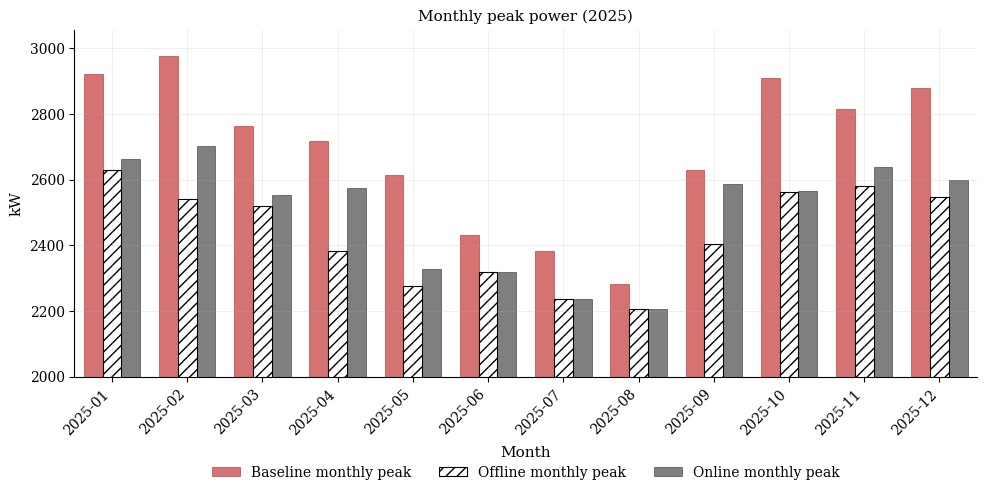

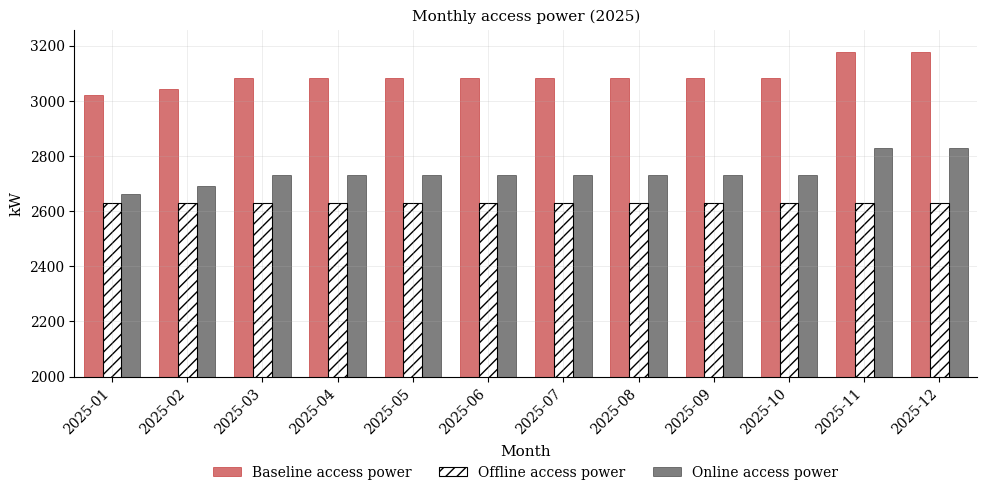

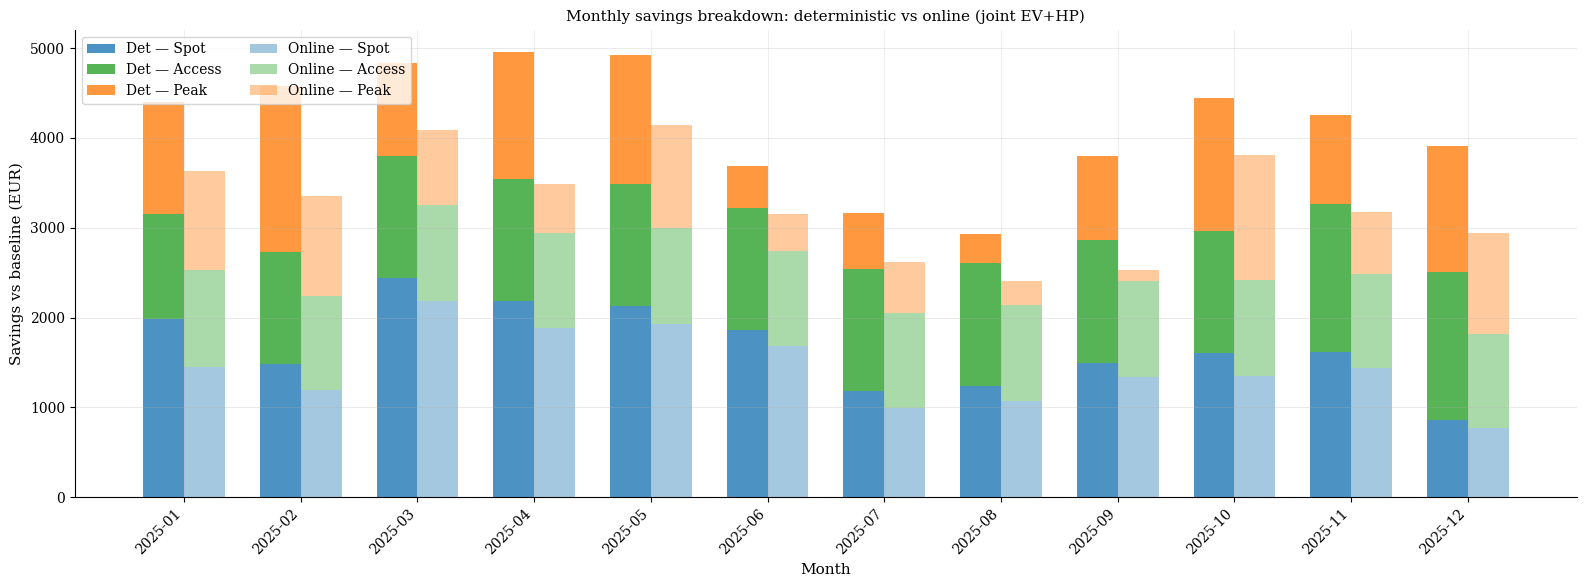


Savings breakdown (first rows):


,month,spot_savings_det,access_power_savings_det,peak_savings_det,total_savings_det,spot_savings_online,access_power_savings_online,peak_savings_online,total_savings_online
0,2025-01,1982.031834,1174.369584,1237.251497,4393.652915,1452.723208,1075.450572,1097.762263,3625.936043
1,2025-02,1487.886485,1237.318045,1848.665477,4573.870007,1187.735616,1055.966524,1105.826307,3349.528447
2,2025-03,2435.094309,1363.214969,1032.869390,4831.178668,2186.814851,1061.961616,841.242934,4090.019401
3,2025-04,2180.390663,1363.214969,1412.208002,4955.813634,1878.878879,1061.961616,550.727850,3491.568344
4,2025-05,2126.163791,1363.214969,1430.927803,4920.306564,1929.328992,1061.961616,1154.904257,4146.194865


In [4]:
# Part 4C — Viewer: Part 3.1 + 3.2 for a chosen scenario export
#
# Loads the Part 4B 15-min CSV only. Rebuilds summary metadata here and writes the
# per-scenario JSON (Part 4B does not create JSON files).

import importlib.util
import sys
from pathlib import Path

import pandas as pd

PROJECT_ROOT = Path("..").resolve()
SRC_DIR = PROJECT_ROOT / "src"
NOTEBOOKS_OUTPUT_DIR = PROJECT_ROOT / "output" / "notebooks"

# --- knobs ---
SCENARIO_SELECT = 1  # scenario_id from Part 4A (1–12)
SCENARIO_NAME_STEM = None  # optional override, e.g. "access_flex_inflex_p50_floor_0p5"
WRITE_SUMMARY_JSON = True  # export online_ev_hp_summary_* .json from CSV + SCENARIOS
WEEK_START = pd.Timestamp("2025-02-10 00:00:00")
DAY_OF_WEEK = 2
DEBUG_TS = pd.Timestamp("2025-02-10 08:00:00")
RUN_MPC_DEBUG = False
RUN_DAY_REPLAY = True

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

import online_MPC_1_EV_HP_scenario_analysis as _scen_mod

_viewer_path = SRC_DIR / "notebook_visualisation" / "nb11_evhp_part34_viewer.py"
_spec = importlib.util.spec_from_file_location("nb11_evhp_part34_viewer", _viewer_path)
_viewer = importlib.util.module_from_spec(_spec)
assert _spec.loader is not None
_spec.loader.exec_module(_viewer)

_sc_sel = None
if SCENARIO_NAME_STEM:
    _stem = SCENARIO_NAME_STEM.strip()
    _matches = sorted(NOTEBOOKS_OUTPUT_DIR.glob(f"online_ev_hp_15min_notebook_11_scenario_*_{_stem}.csv"))
    if not _matches:
        raise FileNotFoundError(f"No scenario CSV for stem {_stem!r}")
    _results_path = _matches[-1]
    if "SCENARIOS" in globals():
        for _s in SCENARIOS:
            if _scen_mod.sanitize_scenario_name_for_filename(_s.name) == _stem or _s.name == _stem:
                _sc_sel = _s
                break
        if _sc_sel is None:
            _sc_sel = _scen_mod.resolve_scenario_for_results_path(SCENARIOS, _results_path)
else:
    _sc_sel = next((s for s in SCENARIOS if s.scenario_id == SCENARIO_SELECT), None) if "SCENARIOS" in globals() else None
    if _sc_sel is None:
        raise ValueError(f"SCENARIO_SELECT={SCENARIO_SELECT} not in SCENARIOS — run Part 4A")
    _id_tag = _scen_mod.scenario_id_tag_for_filename(_sc_sel.scenario_id)
    _safe = _scen_mod.sanitize_scenario_name_for_filename(_sc_sel.name)
    _results_path = NOTEBOOKS_OUTPUT_DIR / f"online_ev_hp_15min_notebook_11_scenario_{_id_tag}_{_safe}.csv"
    if not _results_path.exists():
        _alt = sorted(NOTEBOOKS_OUTPUT_DIR.glob(f"online_ev_hp_15min_notebook_11_scenario_{_id_tag}_*.csv"))
        if not _alt:
            raise FileNotFoundError(f"Run Part 4B first: {_results_path}")
        _results_path = _alt[-1]

if _sc_sel is None:
    _sc_sel = _scen_mod.resolve_scenario_for_results_path(SCENARIOS, _results_path) if "SCENARIOS" in globals() else None
if _sc_sel is None:
    raise ValueError(f"Could not match {_results_path.name} to Part 4A SCENARIOS")

res_evhp_online = pd.read_csv(_results_path)
summ_evhp_online = _scen_mod.build_summary_dict_from_results(PROJECT_ROOT, res_evhp_online, _sc_sel)

_summ_path = _scen_mod.summary_json_path_for_scenario(NOTEBOOKS_OUTPUT_DIR, _sc_sel)
if WRITE_SUMMARY_JSON:
    _scen_mod.write_ev_hp_summary_json(_summ_path, summ_evhp_online)
    print(f"Wrote summary JSON: {_summ_path.name}")

ONLINE_ACCESS_POWER_MODE = _sc_sel.access_power_mode
INFLEX_FORECAST_STRATEGY = _sc_sel.forecast_strategy_inflex
INFLEX_FORECAST_STRATEGY_STRESS = _sc_sel.forecast_strategy_inflex_stress or ""
FORECAST_STRESS_SOC_FLOOR_STRENGTH = _sc_sel.forecast_stress_soc_floor_strength

print(f"Part 4C — {_results_path.name} (access: {ONLINE_ACCESS_POWER_MODE})")

_viewer.run_notebook11_part31_optimized_volumes(
    res_evhp_online,
    PROJECT_ROOT,
    week_start=WEEK_START,
    day_of_week=DAY_OF_WEEK,
    debug_ts=DEBUG_TS,
    run_mpc_debug=RUN_MPC_DEBUG,
    run_day_replay=RUN_DAY_REPLAY,
)
_viewer.run_notebook11_part32_billing_comparison(
    res_evhp_online,
    PROJECT_ROOT,
    summ_evhp_online=summ_evhp_online,
    online_access_power_mode=ONLINE_ACCESS_POWER_MODE,
)


### 4D — Savings comparison


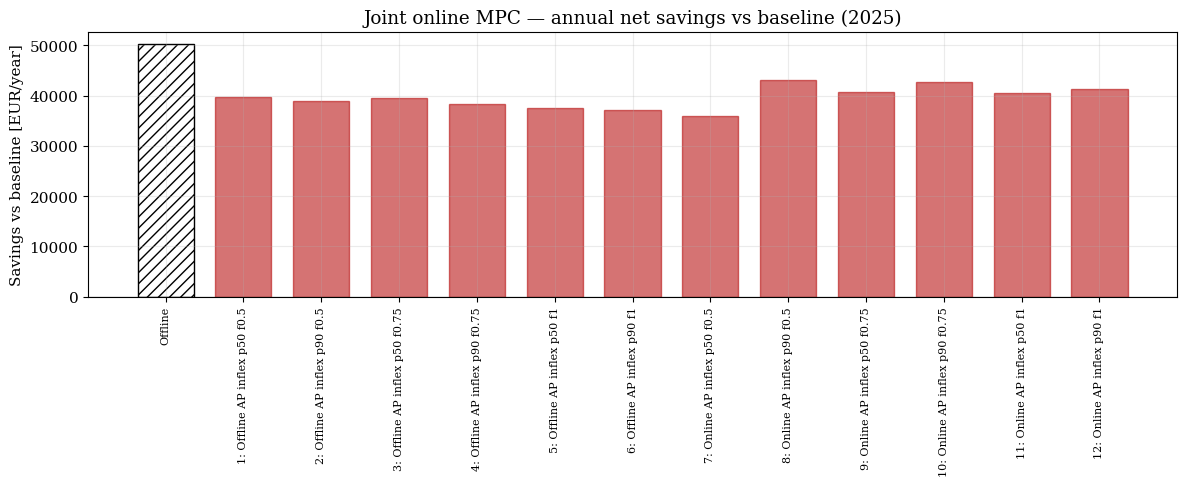

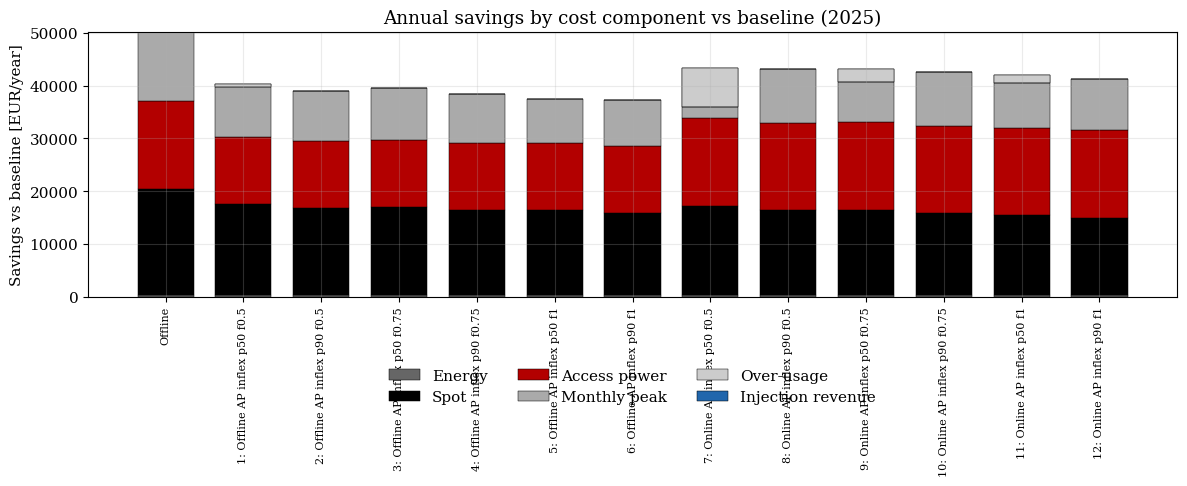


Scenario comparison table:


,scenario_id,scenario_name,access_power_mode,forecast_strategy_inflex,forecast_strategy_inflex_stress,forecast_stress_soc_floor_strength,online_net_cost_eur,savings_vs_baseline_eur,savings_vs_deterministic_eur
6,7,access_det_inflex_p50_floor_0p5,deterministic,c_p50,c_p99,0.50,1.769347e+06,35901.458403,-14355.378146
7,8,access_det_inflex_p90_floor_0p5,deterministic,c_p90,c_p99,0.50,1.762054e+06,43193.649775,-7063.186774
8,9,access_det_inflex_p50_floor_0p75,deterministic,c_p50,c_p99,0.75,1.764562e+06,40686.391163,-9570.445386
9,10,access_det_inflex_p90_floor_0p75,deterministic,c_p90,c_p99,0.75,1.762616e+06,42632.501451,-7624.335097
10,11,access_det_inflex_p50_floor_1p0,deterministic,c_p50,c_p99,1.00,1.764775e+06,40473.352967,-9783.483582
11,12,access_det_inflex_p90_floor_1p0,deterministic,c_p90,c_p99,1.00,1.764002e+06,41245.545340,-9011.291209
0,1,access_flex_inflex_p50_floor_0p5,flex_aware,c_p50,c_p99,0.50,1.765579e+06,39669.137042,-10587.699506
1,2,access_flex_inflex_p90_floor_0p5,flex_aware,c_p90,c_p99,0.50,1.766272e+06,38975.939660,-11280.896888
2,3,access_flex_inflex_p50_floor_0p75,flex_aware,c_p50,c_p99,0.75,1.765715e+06,39532.536254,-10724.300294
3,4,access_flex_inflex_p90_floor_0p75,flex_aware,c_p90,c_p99,0.75,1.766847e+06,38400.986135,-11855.850413


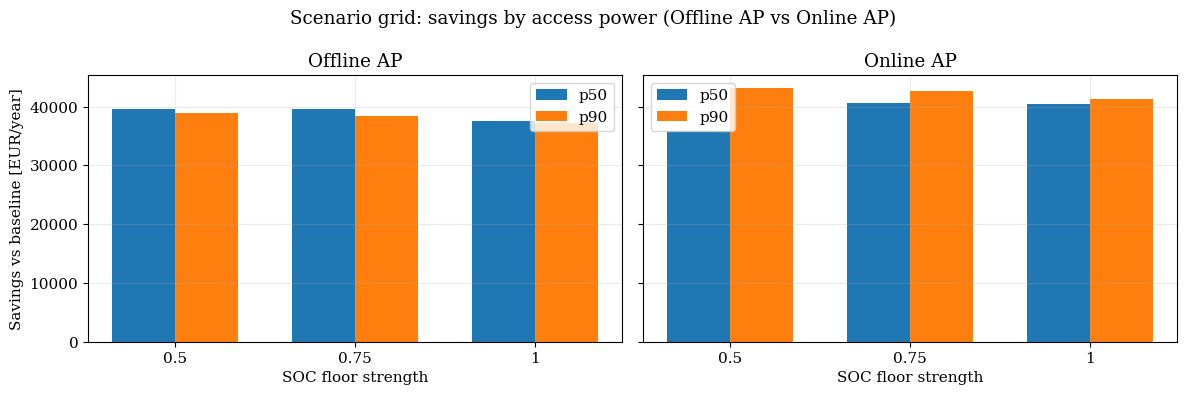


Savings vs baseline [EUR/year] — component table:


,Offline,1: Offline AP inflex p50 f0.5,2: Offline AP inflex p90 f0.5,3: Offline AP inflex p50 f0.75,4: Offline AP inflex p90 f0.75,5: Offline AP inflex p50 f1,6: Offline AP inflex p90 f1,7: Online AP inflex p50 f0.5,8: Online AP inflex p90 f0.5,9: Online AP inflex p50 f0.75,10: Online AP inflex p90 f0.75,11: Online AP inflex p50 f1,12: Online AP inflex p90 f1
Energy,381,311,296,295,283,277,268,301,286,281,269,256,247
Spot,"20,076","17,292","16,516","16,755","16,104","16,055","15,553","16,904","16,103","16,188","15,510","15,192","14,678"
Access power,"16,610","12,718","12,718","12,718","12,718","12,718","12,718","16,610","16,610","16,610","16,610","16,610","16,610"
Monthly peak,"13,189","9,947","9,440","9,759","9,290","8,443","8,699","9,531","10,189","10,107","10,237","10,039","9,704"
Over-usage,0,-605,-0,-0,-0,-0,-0,"-7,451",-0,"-2,505",-0,"-1,631",-0
Injection revenue,-0,6,6,6,6,6,6,6,6,6,6,6,6
Total savings,"50,257","39,669","38,976","39,533","38,401","37,498","37,243","35,901","43,194","40,686","42,633","40,473","41,246"


In [33]:
# Part 4D — Savings vs baseline (all scenarios, thesis style)

import importlib.util
import sys
from pathlib import Path

PROJECT_ROOT = Path("..").resolve()
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

_viewer_path = SRC_DIR / "notebook_visualisation" / "nb11_evhp_part34_viewer.py"
_spec = importlib.util.spec_from_file_location("nb11_evhp_part34_viewer_4d", _viewer_path)
_viewer = importlib.util.module_from_spec(_spec)
assert _spec.loader is not None
_spec.loader.exec_module(_viewer)

_viewer.run_notebook11_part4d_scenario_savings(PROJECT_ROOT)
